In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import pymc as pm
import plotly.io as pio

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
data_previous= pd.read_csv(r'C:\Users\Muslim Aqeel\Downloads\Data-Previous-Ads Manager-After.csv')

In [3]:
data_previous

,Age,Gender,Ad name,Reach,Impressions,Frequency,Result Type,Results,Cost per result,Amount spent (PKR),"CPM (cost per 1,000 impressions)",Link clicks,CPC (cost per link click),CTR (link click-through rate),Reporting starts,Reporting ends,Creative
0,65+,female,New Creative Free Ad Website Traffic | Saqib |...,4106,4223,1.028495,Website purchases,5.0,21380.140330,106900.701700,25313.924140,193.0,553.889646,4.570211,6/1/2024,8/27/2024,NaN
1,55-64,female,New Creative Free Ad Website Traffic | Saqib |...,2260,2260,1.000000,NaN,NaN,NaN,49919.792090,22088.403580,61.0,818.357247,2.699115,6/1/2024,8/27/2024,NaN
2,25-34,male,Sale My Car | Traffic Campaign | Saqib | 10th ...,374678,666812,1.779694,Link clicks,4555.0,2.845689,12962.114370,19.438934,4555.0,2.845689,0.683101,6/1/2024,8/27/2024,NaN
3,45-54,female,New Creative Free Ad Website Traffic | Saqib |...,786,786,1.000000,NaN,NaN,NaN,12436.895300,15823.022000,20.0,621.844765,2.544529,6/1/2024,8/27/2024,NaN
4,25-34,male,New Creative Free Ad Website Traffic | Saqib |...,363796,643148,1.767881,Link clicks,3951.0,3.059478,12087.996210,18.795046,3951.0,3.059478,0.614322,6/1/2024,8/27/2024,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,65+,unknown,Car insurance video traffic campaign | 10 july,0,1,0.000000,NaN,NaN,NaN,0.029915,29.914754,NaN,NaN,NaN,6/1/2024,8/27/2024,NaN
610,65+,unknown,Inspection Campaign | Saqib | 6 June | Multipl...,0,1,0.000000,NaN,NaN,NaN,0.019973,19.973412,NaN,NaN,NaN,6/1/2024,8/27/2024,image
611,65+,unknown,Inspection hasan video campaign | 6th July | C...,0,1,0.000000,NaN,NaN,NaN,0.019968,19.968051,NaN,NaN,NaN,6/1/2024,8/27/2024,video
612,55-64,unknown,Adnan Suicide Inspection Video Campaign | 25 July,0,1,0.000000,NaN,NaN,NaN,0.019948,19.948419,NaN,NaN,NaN,6/1/2024,8/27/2024,video


In [4]:
data_previous = data_previous.dropna(subset=['Creative'])

In [5]:
data_previous 


,Age,Gender,Ad name,Reach,Impressions,Frequency,Result Type,Results,Cost per result,Amount spent (PKR),"CPM (cost per 1,000 impressions)",Link clicks,CPC (cost per link click),CTR (link click-through rate),Reporting starts,Reporting ends,Creative
5,25-34,male,Inspection Video Engagement Campaign | Saqib |...,32048,63370,1.977346,Messaging conversations started,53.0,199.963166,10598.047830,167.240774,140.0,75.700342,0.220925,6/1/2024,8/27/2024,video
8,35-44,male,Inspection Video Engagement Campaign | Saqib |...,20258,41415,2.044378,Messaging conversations started,54.0,160.781466,8682.199148,209.638999,103.0,84.293196,0.248702,6/1/2024,8/27/2024,video
9,25-34,male,New Inspection Campaign | Saqib | 29 June,27872,64790,2.324555,Messaging conversations started,102.0,84.705644,8639.975658,133.353537,336.0,25.714213,0.518599,6/1/2024,8/27/2024,video
11,35-44,male,New Inspection Campaign | Saqib | 29 June,24906,59259,2.379306,Messaging conversations started,88.0,92.250343,8118.030148,136.992358,336.0,24.160804,0.567002,6/1/2024,8/27/2024,image
12,25-34,male,Inspection hasan video campaign | 6th July | C...,39247,89907,2.290799,Messaging conversations started,163.0,47.339472,7716.333899,85.825730,412.0,18.728966,0.458251,6/1/2024,8/27/2024,video
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,65+,female,Adnan Suicide Inspection Video Campaign | 25 July,0,1,0.000000,NaN,NaN,NaN,0.049871,49.871048,NaN,NaN,NaN,6/1/2024,8/27/2024,video
610,65+,unknown,Inspection Campaign | Saqib | 6 June | Multipl...,0,1,0.000000,NaN,NaN,NaN,0.019973,19.973412,NaN,NaN,NaN,6/1/2024,8/27/2024,image
611,65+,unknown,Inspection hasan video campaign | 6th July | C...,0,1,0.000000,NaN,NaN,NaN,0.019968,19.968051,NaN,NaN,NaN,6/1/2024,8/27/2024,video
612,55-64,unknown,Adnan Suicide Inspection Video Campaign | 25 July,0,1,0.000000,NaN,NaN,NaN,0.019948,19.948419,NaN,NaN,NaN,6/1/2024,8/27/2024,video


In [6]:
data_previous = data_previous[data_previous['Gender'] != 'unknown']
print(data_previous['Gender'].value_counts())

Gender
female    138
male      136
Name: count, dtype: int64


In [7]:
data_previous['Gender'].unique()

array(['male', 'female'], dtype=object)

In [8]:
data_previous

,Age,Gender,Ad name,Reach,Impressions,Frequency,Result Type,Results,Cost per result,Amount spent (PKR),"CPM (cost per 1,000 impressions)",Link clicks,CPC (cost per link click),CTR (link click-through rate),Reporting starts,Reporting ends,Creative
5,25-34,male,Inspection Video Engagement Campaign | Saqib |...,32048,63370,1.977346,Messaging conversations started,53.0,199.963166,10598.047830,167.240774,140.0,75.700342,0.220925,6/1/2024,8/27/2024,video
8,35-44,male,Inspection Video Engagement Campaign | Saqib |...,20258,41415,2.044378,Messaging conversations started,54.0,160.781466,8682.199148,209.638999,103.0,84.293196,0.248702,6/1/2024,8/27/2024,video
9,25-34,male,New Inspection Campaign | Saqib | 29 June,27872,64790,2.324555,Messaging conversations started,102.0,84.705644,8639.975658,133.353537,336.0,25.714213,0.518599,6/1/2024,8/27/2024,video
11,35-44,male,New Inspection Campaign | Saqib | 29 June,24906,59259,2.379306,Messaging conversations started,88.0,92.250343,8118.030148,136.992358,336.0,24.160804,0.567002,6/1/2024,8/27/2024,image
12,25-34,male,Inspection hasan video campaign | 6th July | C...,39247,89907,2.290799,Messaging conversations started,163.0,47.339472,7716.333899,85.825730,412.0,18.728966,0.458251,6/1/2024,8/27/2024,video
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,65+,female,Rasha Inspection Campaign | Multiple Adset | 2...,2,5,2.500000,NaN,NaN,NaN,1.208657,241.731414,NaN,NaN,NaN,6/1/2024,8/27/2024,image
559,55-64,female,Rasha Inspection Campaign | Multiple Adset | 2...,6,11,1.833333,NaN,NaN,NaN,1.149198,104.472508,NaN,NaN,NaN,6/1/2024,8/27/2024,image
578,65+,female,Rasha Inspection Campaign | Multiple Adset | 2...,4,7,1.750000,NaN,NaN,NaN,0.729491,104.212949,NaN,NaN,NaN,6/1/2024,8/27/2024,image
608,65+,female,Adnan Suicide Inspection Video Campaign | 25 July,0,1,0.000000,NaN,NaN,NaN,0.049871,49.871048,NaN,NaN,NaN,6/1/2024,8/27/2024,video


In [9]:
data_previous = data_previous.dropna(subset=['Link clicks'])
data_previous.isnull().sum()

Age                                  0
Gender                               0
Ad name                              0
Reach                                0
Impressions                          0
Frequency                            0
Result Type                         54
Results                             54
Cost per result                     54
Amount spent (PKR)                   0
CPM (cost per 1,000 impressions)     0
Link clicks                          0
CPC (cost per link click)            0
CTR (link click-through rate)        0
Reporting starts                     0
Reporting ends                       0
Creative                             0
dtype: int64

## Exploratory Data Analysis

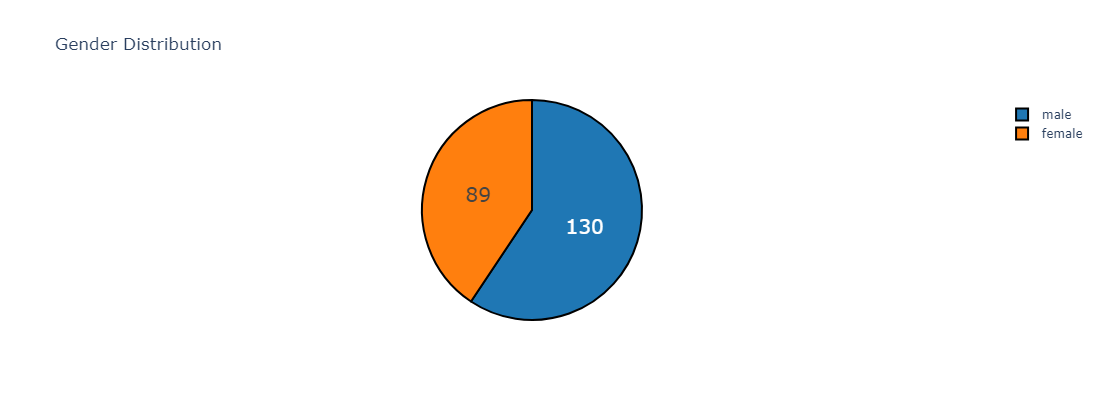

In [10]:
gender_counts = data_previous['Gender'].value_counts()
labels = gender_counts.index.tolist()
values = gender_counts.values.tolist()

colors = ['#1f77b4', '#ff7f0e']  

fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=values
)])

fig.update_traces(
    hoverinfo='label+percent',  
    textinfo='value',  
    textfont_size=20, 
    marker=dict(
        colors=colors,  
        line=dict(color='#000000', width=2)  
    )
)

fig.update_layout(
    title='Gender Distribution',
    autosize=False,
    width=600,  
    height=400  
)

fig.show()
pio.write_image(fig, 'reach_by_age_gender.png')

C:\Users\Muslim Aqeel\AppData\Local\Temp\ipykernel_8464\2898267720.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




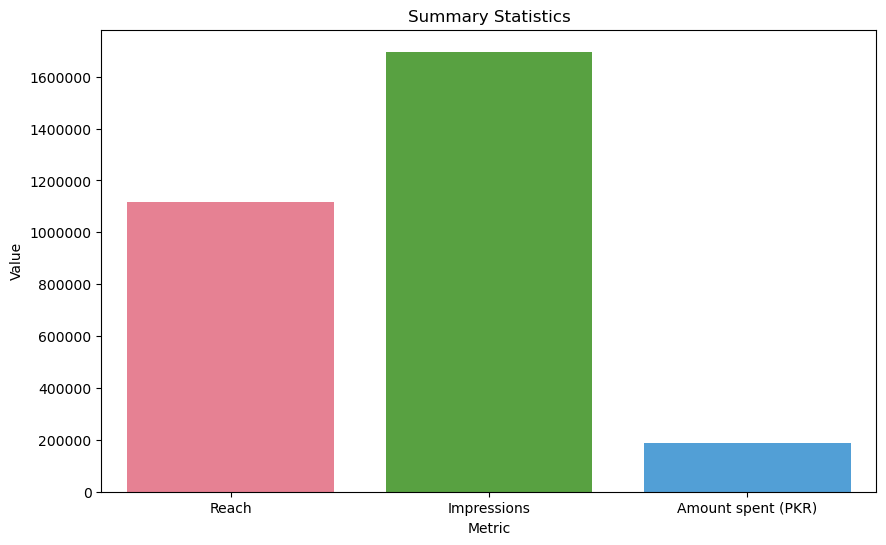

In [11]:
total_reach = data_previous['Reach'].sum()
total_impression = data_previous['Impressions'].sum()
total_amount = data_previous['Amount spent (PKR)'].sum()

d_summary = pd.DataFrame({
    'Metric': ['Reach', 'Impressions', 'Amount spent (PKR)'],
    'Value': [total_reach, total_impression, total_amount]
})

plt.figure(figsize=(10, 6))
colors = sns.color_palette("husl", len(d_summary))
sns.barplot(x='Metric', y='Value', data=d_summary, palette=colors)
plt.title('Summary Statistics')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [12]:
data_agg = data_previous.groupby(['Age', 'Gender']).agg({
    'Reach': 'sum',
    'Impressions': 'sum',
    'Amount spent (PKR)': 'sum',
    'Link clicks': 'sum'
}).reset_index()

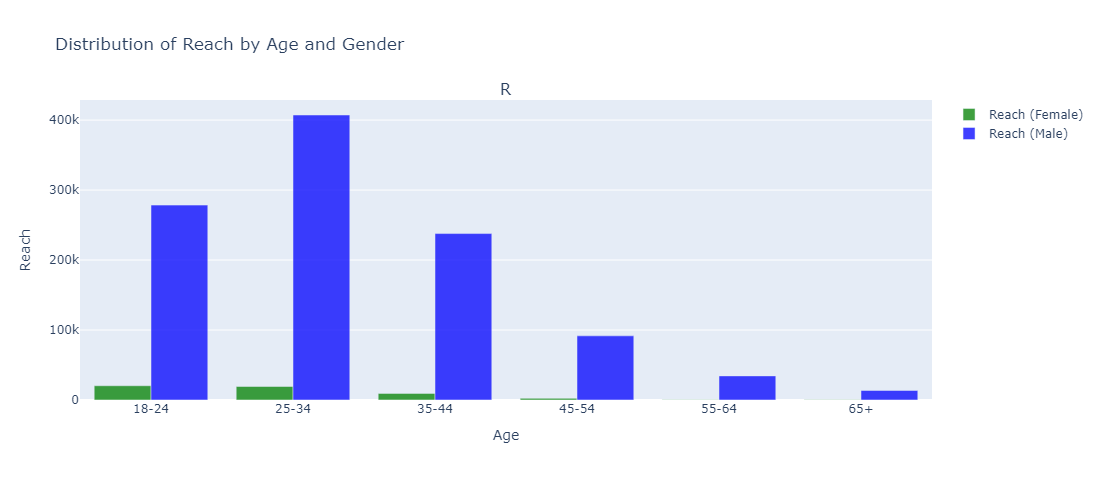

In [13]:
data_agg['Gender'] = data_agg['Gender'].str.strip().str.capitalize()
colors = {'Male': 'blue', 'Female': 'green'}

fig = make_subplots(rows=1, cols=1, subplot_titles=('Reach by Age and Gender'))

for gender in data_agg['Gender'].unique():
    filtered_data = data_agg[data_agg['Gender'] == gender]
    fig.add_trace(go.Bar(
        x=filtered_data['Age'],
        y=filtered_data['Reach'],
        name=f'Reach ({gender})',
        marker_color=colors.get(gender, 'gray'),  
        opacity=0.75  
    ), row=1, col=1)

fig.update_layout(
    title_text='Distribution of Reach by Age and Gender',
    xaxis_title='Age',
    yaxis_title='Reach',
    width=850,  
    height=480,  
    barmode='group'  
)

fig.show()
pio.write_image(fig, 'reach_by_age_gender.png')

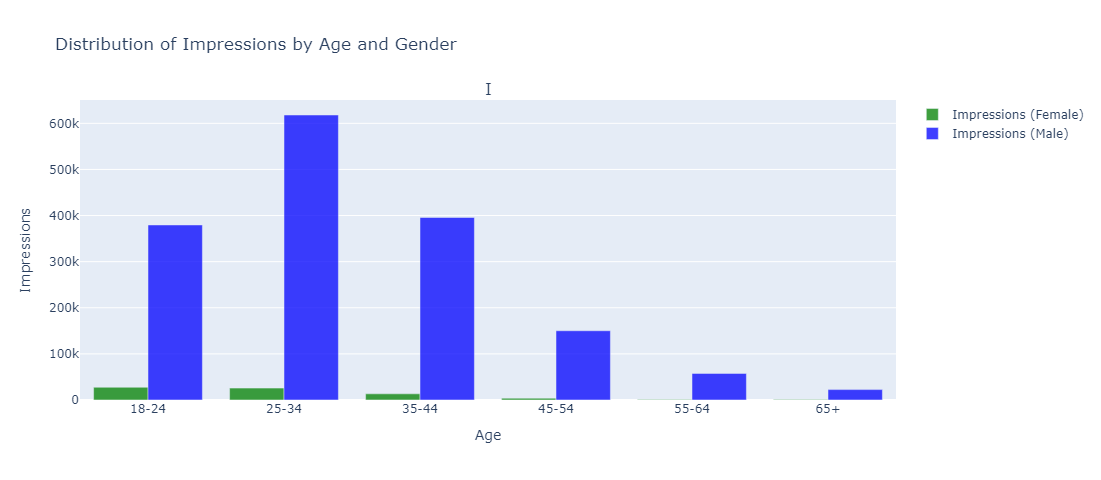

In [14]:
colors = {'Male': 'blue', 'Female': 'green'}

fig = make_subplots(rows=1, cols=1, subplot_titles=('Impressions by Age and Gender'))

for gender in data_agg['Gender'].unique():
    filtered_data = data_agg[data_agg['Gender'] == gender]
    fig.add_trace(go.Bar(
        x=filtered_data['Age'],
        y=filtered_data['Impressions'],
        name=f'Impressions ({gender})',
        marker_color=colors.get(gender, 'gray'),  
        opacity=0.75  # Set opacity to 0.75
    ), row=1, col=1)

# Update layout with increased size
fig.update_layout(
    title_text='Distribution of Impressions by Age and Gender',
    xaxis_title='Age',
    yaxis_title='Impressions',
    width=850,  
    height=480,  
    barmode='group'  
)

fig.show()

In [15]:
data_agg['CPC (cost per link click)']= data_agg['Amount spent (PKR)'] / data_agg['Link clicks']
data_agg['CTR']= data_agg['Link clicks'] / data_agg['Impressions']

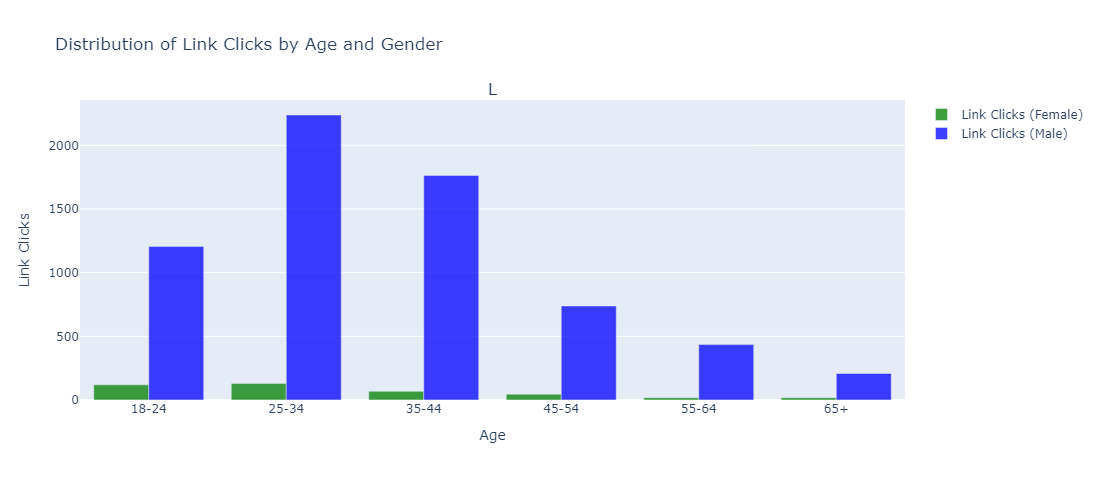

In [16]:
colors = {'Male': 'blue', 'Female': 'green'}

fig = make_subplots(rows=1, cols=1, subplot_titles=('Link Clicks by Age and Gender'))

for gender in data_agg['Gender'].unique():
    filtered_data = data_agg[data_agg['Gender'] == gender]
    fig.add_trace(go.Bar(
        x=filtered_data['Age'],
        y=filtered_data['Link clicks'],
        name=f'Link Clicks ({gender})',
        marker_color=colors.get(gender, 'gray'),  
        opacity=0.75  
    ), row=1, col=1)

fig.update_layout(
    title_text='Distribution of Link Clicks by Age and Gender',
    xaxis_title='Age',
    yaxis_title='Link Clicks',
    width=850,  
    height=480, 
    barmode='group' 
)

fig.show()

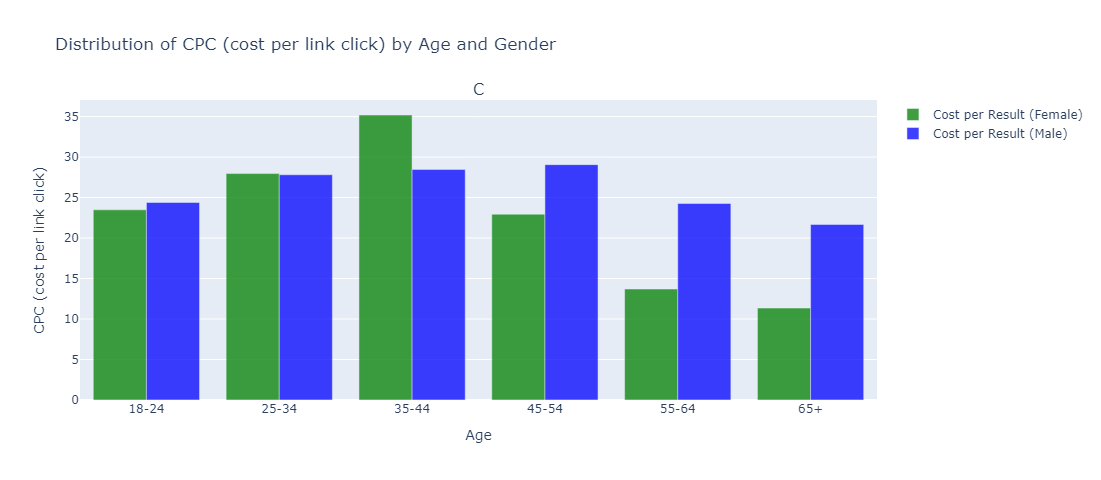

In [17]:
colors = {'Male': 'blue', 'Female': 'green'}

fig_cost_per_result = make_subplots(rows=1, cols=1, subplot_titles=('CPC (cost per link click) by Age and Gender'))

for gender in data_agg['Gender'].unique():
    filtered_data = data_agg[data_agg['Gender'] == gender]
    
    fig_cost_per_result.add_trace(go.Bar(
        x=filtered_data['Age'],
        y=filtered_data['CPC (cost per link click)'],
        name=f'Cost per Result ({gender})',
        marker_color=colors.get(gender, 'gray'),  
        opacity=0.75  
    ))

fig_cost_per_result.update_layout(
    title_text='Distribution of CPC (cost per link click) by Age and Gender',
    xaxis_title='Age',
    yaxis_title='CPC (cost per link click)',
    width=850,  
    height=480,  
    barmode='group'  
)

# Show the plot
fig_cost_per_result.show()

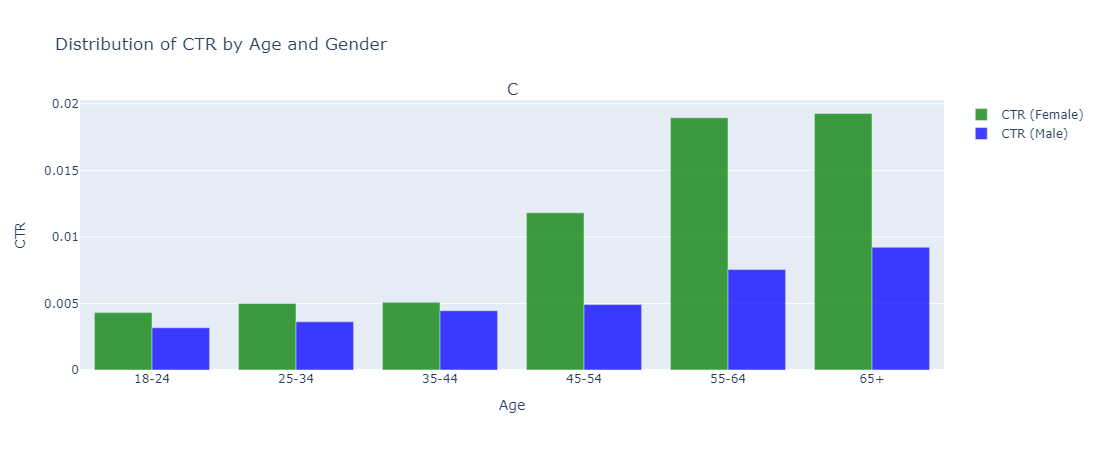

In [18]:
fig_ctr = make_subplots(rows=1, cols=1, subplot_titles=('CTR by Age and Gender'))

for gender in data_agg['Gender'].unique():
    filtered_data = data_agg[data_agg['Gender'] == gender]
    
    fig_ctr.add_trace(go.Bar(
        x=filtered_data['Age'],
        y=filtered_data['CTR'],
        name=f'CTR ({gender})',
        marker_color=colors.get(gender, 'gray'),  
        opacity=0.75 
    ))

fig_ctr.update_layout(
    title_text='Distribution of CTR by Age and Gender',
    xaxis_title='Age',
    yaxis_title='CTR',
    width=880,  
    height=450,  
    barmode='group'  
)

# Show the plot
fig_ctr.show()

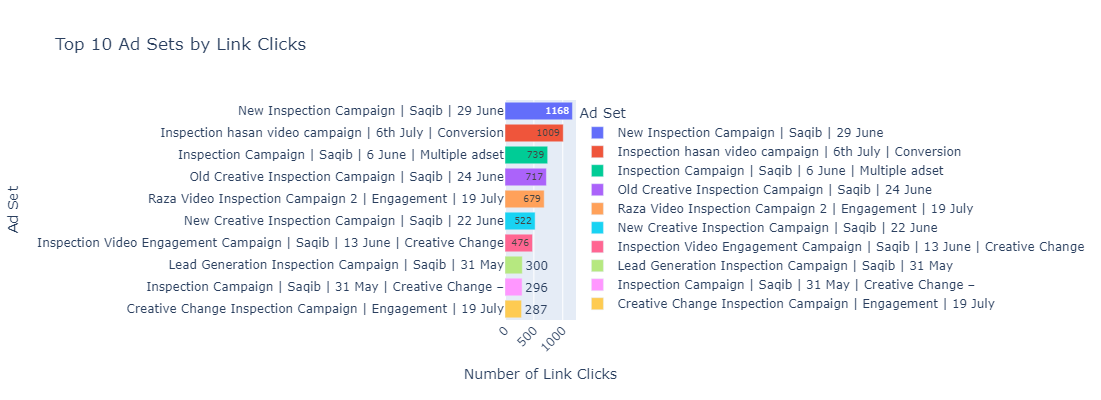

In [19]:
adset_link_clicks = data_previous.groupby('Ad name')['Link clicks'].sum().reset_index()

top_10_adsets = adset_link_clicks.sort_values(by='Link clicks', ascending=False).head(10)

fig = px.bar(top_10_adsets, 
             x='Link clicks', 
             y='Ad name', 
             title='Top 10 Ad Sets by Link Clicks',
             labels={'Link clicks': 'Number of Link Clicks', 'Ad name': 'Ad Set'},
             orientation='h', 
             color='Ad name',  
             color_discrete_sequence=px.colors.qualitative.Plotly,
             text='Link clicks')  

fig.update_layout(
    xaxis_title='Number of Link Clicks',
    yaxis_title='Ad Set',
    width=1400,  
    height=400,  
    xaxis=dict(tickangle=-45)  
)

fig.show()

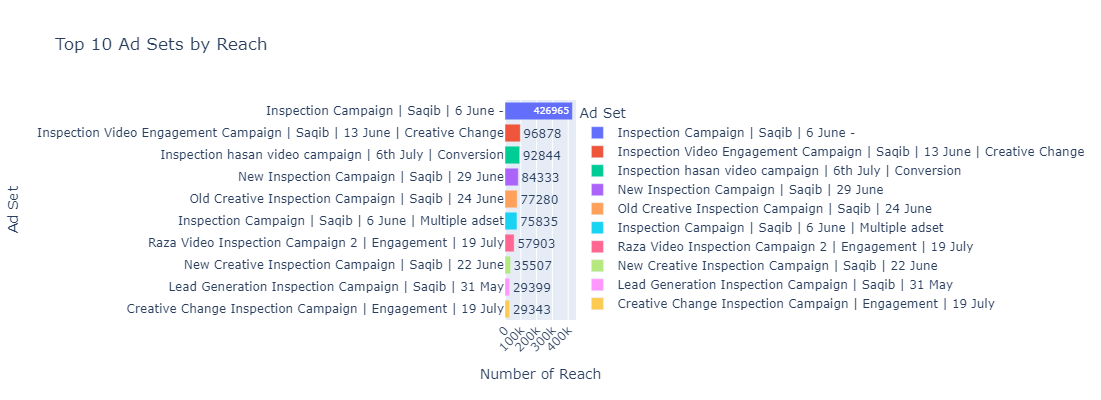

In [20]:
adset_reach = data_previous.groupby('Ad name')['Reach'].sum().reset_index()

top_10_adsets_reach = adset_reach.sort_values(by='Reach', ascending=False).head(10)

fig = px.bar(top_10_adsets_reach, 
             x='Reach', 
             y='Ad name', 
             title='Top 10 Ad Sets by Reach',
             labels={'Reach': 'Number of Reach', 'Ad name': 'Ad Set'},
             orientation='h', 
             color='Ad name',  
             color_discrete_sequence=px.colors.qualitative.Plotly,
             text='Reach')  

fig.update_layout(
    xaxis_title='Number of Reach',
    yaxis_title='Ad Set',
    width=1400,  
    height=400,  
    xaxis=dict(tickangle=-45)  
)


fig.show()

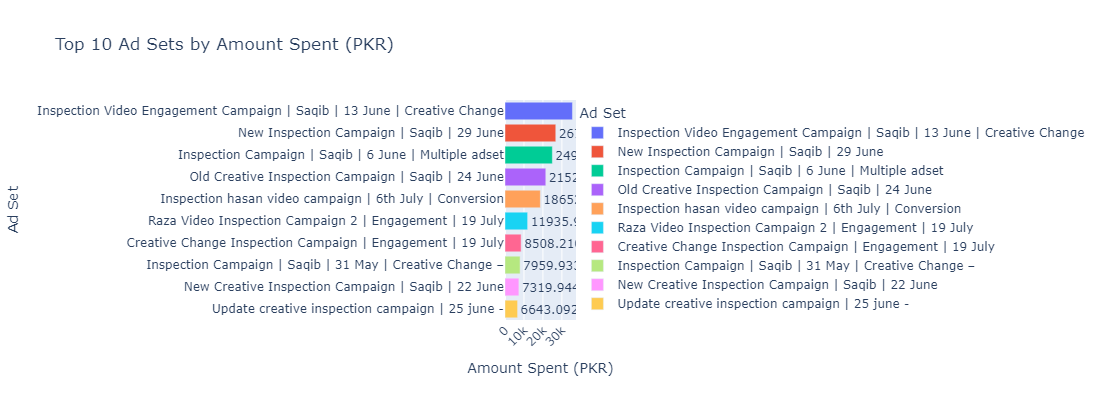

In [21]:
adset_amount_spent = data_previous.groupby('Ad name')['Amount spent (PKR)'].sum().reset_index()
top_10_adsets_amount_spent = adset_amount_spent.sort_values(by='Amount spent (PKR)', ascending=False).head(10)

fig = px.bar(top_10_adsets_amount_spent, 
             x='Amount spent (PKR)', 
             y='Ad name', 
             title='Top 10 Ad Sets by Amount Spent (PKR)',
             labels={'Amount spent (PKR)': 'Amount Spent (PKR)', 'Ad name': 'Ad Set'},
             orientation='h', 
             color='Ad name',  
             color_discrete_sequence=px.colors.qualitative.Plotly,
             text='Amount spent (PKR)')  

fig.update_layout(
    xaxis_title='Amount Spent (PKR)',
    yaxis_title='Ad Set',
    width=1400,  
    height=400,  
    xaxis=dict(tickangle=-45) 
)



fig.show()

C:\Users\Muslim Aqeel\AppData\Local\Temp\ipykernel_8464\2427496308.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



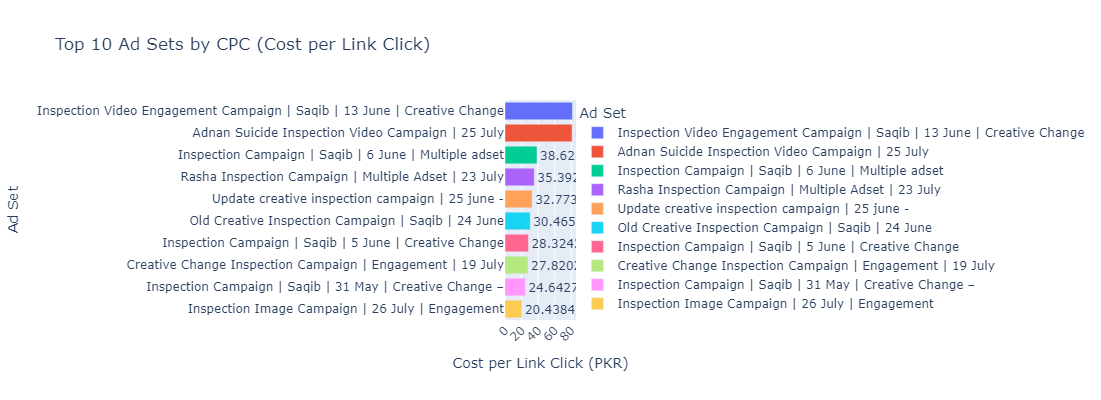

In [22]:
data_previous['CPC'] = data_previous['Amount spent (PKR)'] / data_previous['Link clicks']

adset_cpc = data_previous.groupby('Ad name')['CPC'].mean().reset_index()

top_10_adsets_cpc = adset_cpc.sort_values(by='CPC', ascending=False).head(10)

fig = px.bar(top_10_adsets_cpc, 
             x='CPC', 
             y='Ad name', 
             title='Top 10 Ad Sets by CPC (Cost per Link Click)',
             labels={'CPC': 'Cost per Link Click (PKR)', 'Ad name': 'Ad Set'},
             orientation='h', 
             color='Ad name',  
             color_discrete_sequence=px.colors.qualitative.Plotly,
             text='CPC')  

fig.update_layout(
    xaxis_title='Cost per Link Click (PKR)',
    yaxis_title='Ad Set',
    width=1400,  
    height=400,  
    xaxis=dict(tickangle=-45)  
)

fig.show()

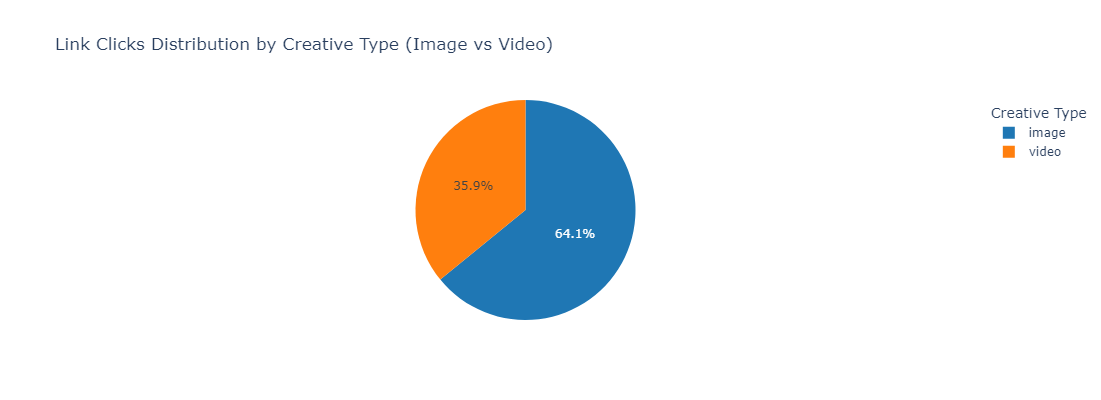

In [23]:
colors = ['#1f77b4', '#ff7f0e']

link_clicks_by_creative = data_previous.groupby('Creative')['Link clicks'].sum().reset_index()

fig = px.pie(link_clicks_by_creative, 
             names='Creative', 
             values='Link clicks',
             title='Link Clicks Distribution by Creative Type (Image vs Video)',
             color_discrete_sequence=colors)

fig.update_layout(
    width=600,
    height=400,
    legend_title='Creative Type',
    showlegend=True,
)

fig.show()

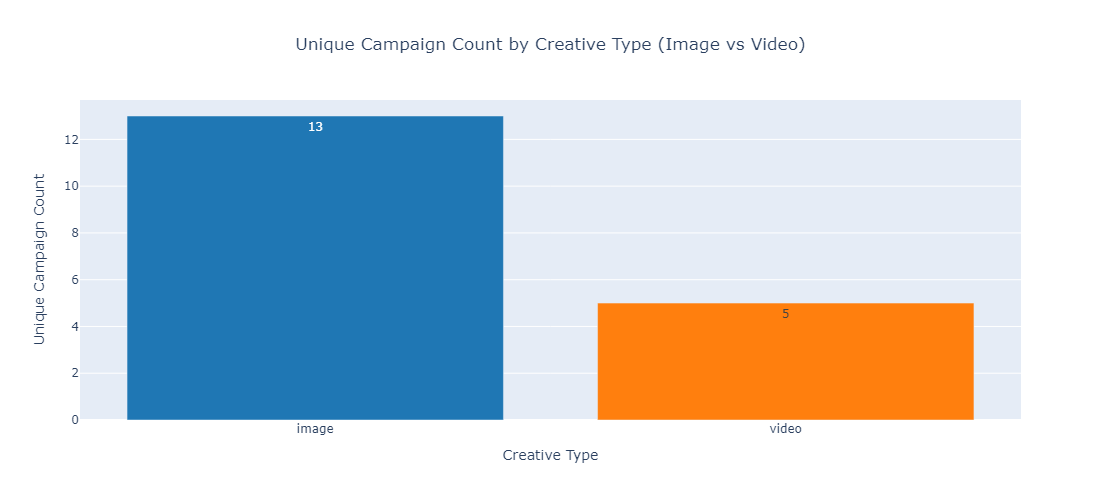

In [24]:
unique_campaigns_by_creative = data_previous.groupby('Creative')['Ad name'].nunique().reset_index()

unique_campaigns_by_creative.columns = ['Creative', 'Unique Campaign Count']

fig = px.bar(unique_campaigns_by_creative, 
             x='Creative', 
             y='Unique Campaign Count', 
             color='Creative',
             title='Unique Campaign Count by Creative Type (Image vs Video)',
             text='Unique Campaign Count',  
             color_discrete_sequence=['#1f77b4', '#ff7f0e'])  


fig.update_layout(
    width=700,
    height=500,
    xaxis_title='Creative Type',
    yaxis_title='Unique Campaign Count',
    showlegend=False,  
    title_x=0.5  
)


fig.show()

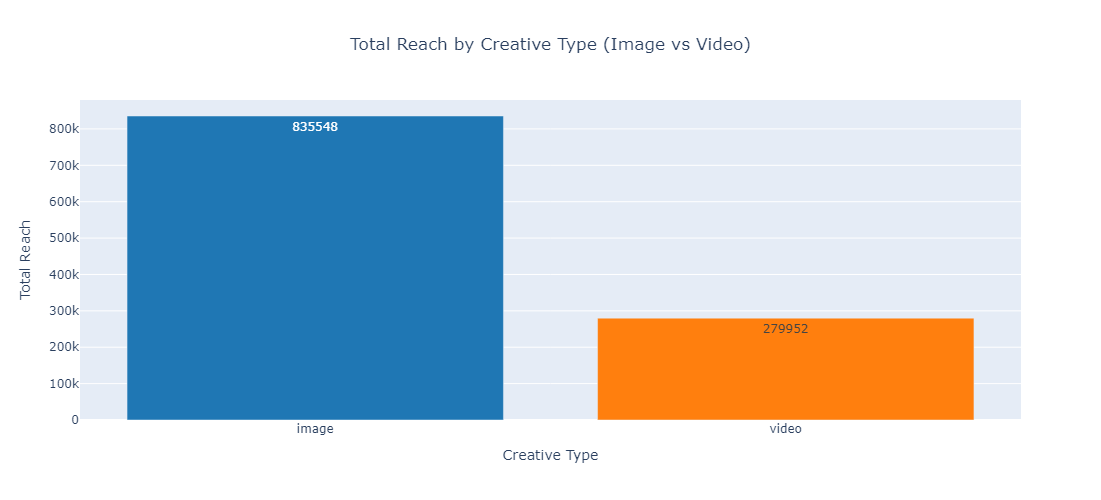

In [25]:


# Group by 'Creative' and calculate the total reach for each type
reach_by_creative = data_previous.groupby('Creative')['Reach'].sum().reset_index()

# Rename columns
reach_by_creative.columns = ['Creative', 'Total Reach']

# Create bar plot using Plotly Express
fig = px.bar(reach_by_creative, 
             x='Creative', 
             y='Total Reach', 
             color='Creative',
             title='Total Reach by Creative Type (Image vs Video)',
             text='Total Reach',  
             color_discrete_sequence=['#1f77b4', '#ff7f0e'])  

# Update layout
fig.update_layout(
    width=700,
    height=500,
    xaxis_title='Creative Type',
    yaxis_title='Total Reach',
    showlegend=False,  
    title_x=0.5  
)

# Show the plot
fig.show()

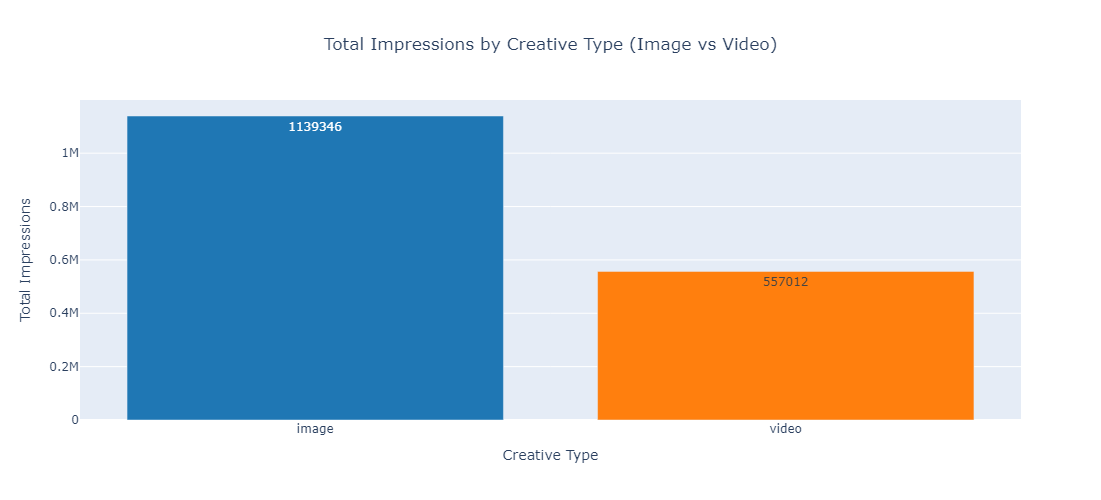

In [26]:
impressions_by_creative = data_previous.groupby('Creative')['Impressions'].sum().reset_index()

# Rename columns
impressions_by_creative.columns = ['Creative', 'Total Impressions']

# Create bar plot for Impressions
fig_impressions = px.bar(impressions_by_creative, 
                         x='Creative', 
                         y='Total Impressions', 
                         color='Creative',
                         title='Total Impressions by Creative Type (Image vs Video)',
                         text='Total Impressions',  
                         color_discrete_sequence=['#1f77b4', '#ff7f0e'])

# Update layout
fig_impressions.update_layout(
    width=700,
    height=500,
    xaxis_title='Creative Type',
    yaxis_title='Total Impressions',
    showlegend=False,
    title_x=0.5
)

# Show the plot
fig_impressions.show()

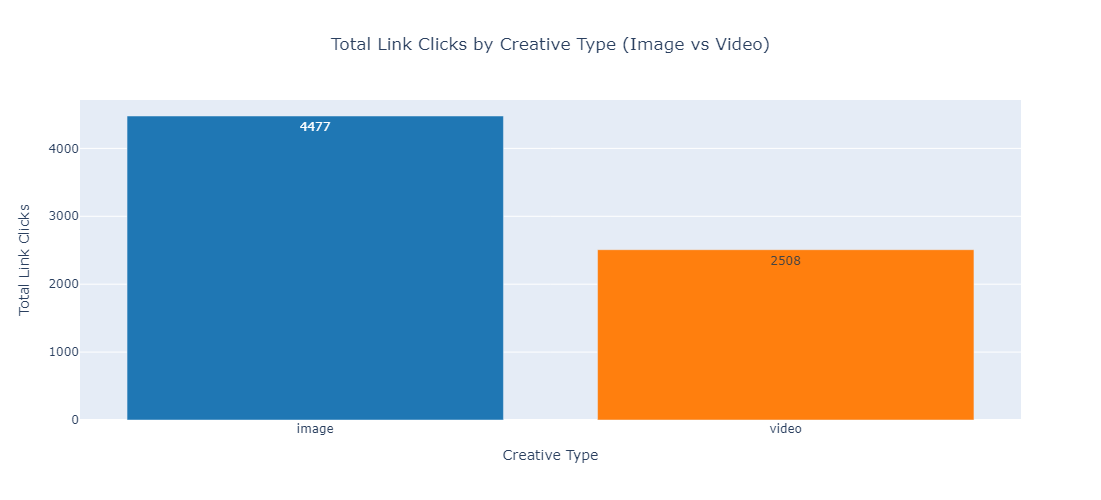

In [27]:
clicks_by_creative = data_previous.groupby('Creative')['Link clicks'].sum().reset_index()

# Rename columns
clicks_by_creative.columns = ['Creative', 'Total Link Clicks']

# Create bar plot for Link Clicks
fig_clicks = px.bar(clicks_by_creative, 
                    x='Creative', 
                    y='Total Link Clicks', 
                    color='Creative',
                    title='Total Link Clicks by Creative Type (Image vs Video)',
                    text='Total Link Clicks',  
                    color_discrete_sequence=['#1f77b4', '#ff7f0e'])

# Update layout
fig_clicks.update_layout(
    width=700,
    height=500,
    xaxis_title='Creative Type',
    yaxis_title='Total Link Clicks',
    showlegend=False,
    title_x=0.5
)

# Show the plot
fig_clicks.show()

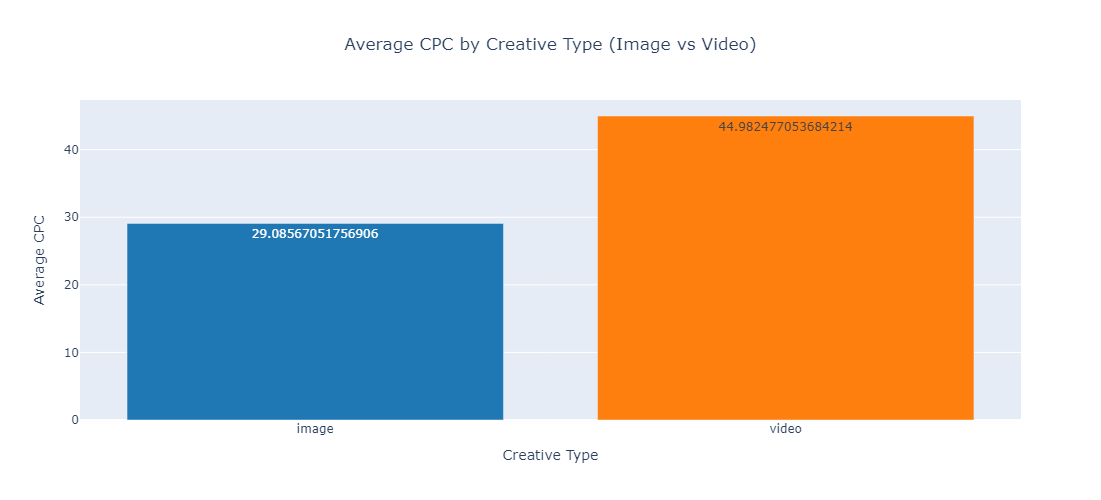

In [28]:
#data_previous['Creative'].fillna('image', inplace=True)

# Group by 'Creative' and calculate the average CPC
cpc_by_creative = data_previous.groupby('Creative')['CPC (cost per link click)'].mean().reset_index()

# Rename columns
cpc_by_creative.columns = ['Creative', 'Average CPC']

# Create bar plot for CPC
fig_cpc = px.bar(cpc_by_creative, 
                 x='Creative', 
                 y='Average CPC', 
                 color='Creative',
                 title='Average CPC by Creative Type (Image vs Video)',
                 text='Average CPC',  
                 color_discrete_sequence=['#1f77b4', '#ff7f0e'])

# Update layout
fig_cpc.update_layout(
    width=700,
    height=500,
    xaxis_title='Creative Type',
    yaxis_title='Average CPC',
    showlegend=False,
    title_x=0.5
)

# Show the plot
fig_cpc.show()

In [29]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
data_previous.columns = data_previous.columns.str.replace(' ', '_')

model = smf.mixedlm('Link_clicks ~ Age', data_previous, groups=data_previous['Ad_name']).fit()

print("Hierarchical Model Summary:")
print(model.summary())


Hierarchical Model Summary:
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Link_clicks
No. Observations: 219     Method:             REML       
No. Groups:       16      Scale:              2840.7142  
Min. group size:  6       Log-Likelihood:     -1169.9776 
Max. group size:  50      Converged:          Yes        
Mean group size:  13.7                                   
---------------------------------------------------------
              Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------
Intercept     38.249   10.892  3.512 0.000  16.901 59.597
Age[T.25-34]  22.593   11.804  1.914 0.056  -0.542 45.728
Age[T.35-44]  11.373   11.950  0.952 0.341 -12.049 34.794
Age[T.45-54] -12.730   12.261 -1.038 0.299 -36.762 11.302
Age[T.55-64] -20.763   12.887 -1.611 0.107 -46.020  4.494
Age[T.65+]   -30.959   13.286 -2.330 0.020 -56.999 -4.919
Group Var    677.010    6.518                         

In [30]:
data_previous['Age'] = data_previous['Age'].replace({'18-24': 1, '25-34': 2, '35-44': 3, '45-54': 4, '55-64': 5, '65+': 6}).astype(int)
data_previous

C:\Users\Muslim Aqeel\AppData\Local\Temp\ipykernel_8464\4051342878.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\Muslim Aqeel\AppData\Local\Temp\ipykernel_8464\4051342878.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Age,Gender,Ad_name,Reach,Impressions,Frequency,Result_Type,Results,Cost_per_result,Amount_spent_(PKR),"CPM_(cost_per_1,000_impressions)",Link_clicks,CPC_(cost_per_link_click),CTR_(link_click-through_rate),Reporting_starts,Reporting_ends,Creative,CPC
5,2,male,Inspection Video Engagement Campaign | Saqib |...,32048,63370,1.977346,Messaging conversations started,53.0,199.963166,10598.047830,167.240774,140.0,75.700342,0.220925,6/1/2024,8/27/2024,video,75.700342
8,3,male,Inspection Video Engagement Campaign | Saqib |...,20258,41415,2.044378,Messaging conversations started,54.0,160.781466,8682.199148,209.638999,103.0,84.293196,0.248702,6/1/2024,8/27/2024,video,84.293196
9,2,male,New Inspection Campaign | Saqib | 29 June,27872,64790,2.324555,Messaging conversations started,102.0,84.705644,8639.975658,133.353537,336.0,25.714213,0.518599,6/1/2024,8/27/2024,video,25.714213
11,3,male,New Inspection Campaign | Saqib | 29 June,24906,59259,2.379306,Messaging conversations started,88.0,92.250343,8118.030148,136.992358,336.0,24.160804,0.567002,6/1/2024,8/27/2024,image,24.160804
12,2,male,Inspection hasan video campaign | 6th July | C...,39247,89907,2.290799,Messaging conversations started,163.0,47.339472,7716.333899,85.825730,412.0,18.728966,0.458251,6/1/2024,8/27/2024,video,18.728966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,6,female,Inspection hasan video campaign | 6th July | C...,32,109,3.406250,Messaging conversations started,1.0,11.202077,11.202077,102.771346,2.0,5.601038,1.834862,6/1/2024,8/27/2024,video,5.601038
423,6,male,Inspection Campaign | Saqib | 5 June | Creativ...,48,53,1.104167,NaN,NaN,NaN,8.845364,166.893652,1.0,8.845364,1.886792,6/1/2024,8/27/2024,image,8.845364
447,4,female,Inspection Campaign | Saqib | 6 June | Multipl...,24,49,2.041667,Messaging conversations started,1.0,6.344475,6.344475,129.479074,1.0,6.344475,2.040816,6/1/2024,8/27/2024,image,6.344475
518,6,female,Inspection Image Campaign | 26 July | Engagement,8,20,2.500000,NaN,NaN,NaN,2.394458,119.722881,1.0,2.394458,5.000000,6/1/2024,8/27/2024,image,2.394458


In [31]:
data_previous.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 5 to 544
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               219 non-null    int32  
 1   Gender                            219 non-null    object 
 2   Ad_name                           219 non-null    object 
 3   Reach                             219 non-null    int64  
 4   Impressions                       219 non-null    int64  
 5   Frequency                         219 non-null    float64
 6   Result_Type                       165 non-null    object 
 7   Results                           165 non-null    float64
 8   Cost_per_result                   165 non-null    float64
 9   Amount_spent_(PKR)                219 non-null    float64
 10  CPM_(cost_per_1,000_impressions)  219 non-null    float64
 11  Link_clicks                       219 non-null    float64
 12  CPC_(cost_per

## Importing New Adset Data

In [32]:
data_after= pd.read_csv(r'C:\Users\Muslim Aqeel\Downloads\Data-New-Adset-After.csv')

In [33]:
data_after

,Age,Gender,Ad name,Reach,Impressions,Frequency,Result Type,Results,Cost per result,Amount spent (PKR),"CPM (cost per 1,000 impressions)",Link clicks,CPC (cost per link click),CTR (link click-through rate),Reporting starts,Reporting ends,Creative
0,25-34,male,Inspection muzammil video campaign | 10 August,26894,51307,1.907749,Messaging conversations started,99.0,104.842793,10379.436550,202.300593,214.0,48.502040,0.417097,8/1/2024,9/5/2024,video
1,25-34,male,Sale my car video campaign | 6th August,49832,101580,2.038449,Link clicks,15115.0,0.668075,10097.957000,99.408909,15115.0,0.668075,14.879898,8/1/2024,9/5/2024,NaN
2,18-24,male,Sale my car video campaign | 6th August,39853,83588,2.097408,Link clicks,12465.0,0.681574,8495.823227,101.639269,12465.0,0.681574,14.912428,8/1/2024,9/5/2024,NaN
3,35-44,male,Sale my car video campaign | 6th August,37422,82655,2.208727,Link clicks,12185.0,0.666027,8115.534949,98.185651,12185.0,0.666027,14.742000,8/1/2024,9/5/2024,NaN
4,25-34,male,Again Run For Narzish Inspection hassan video ...,28180,48814,1.732221,Messaging conversations started,71.0,109.279767,7758.863475,158.947504,180.0,43.104797,0.368747,8/1/2024,9/5/2024,video
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,18-24,unknown,Car Insurance Shehzad Video Campaign | 9 July,1,1,1.000000,NaN,NaN,NaN,0.049901,49.901083,NaN,NaN,NaN,8/1/2024,9/5/2024,NaN
506,65+,unknown,New Creative Inspection Image Campaign | 17th ...,0,1,0.000000,NaN,NaN,NaN,0.049640,49.639609,NaN,NaN,NaN,8/1/2024,9/5/2024,image
507,55-64,unknown,For Website Animated Inspection Image Campaign...,6,6,1.000000,NaN,NaN,NaN,0.039796,6.632614,NaN,NaN,NaN,8/1/2024,9/5/2024,image
508,65+,unknown,For Website Animated Inspection Image Campaign...,0,1,0.000000,NaN,NaN,NaN,0.019898,19.897841,NaN,NaN,NaN,8/1/2024,9/5/2024,image


In [34]:
data_after = data_after.dropna(subset=['Creative'])

In [35]:
data_after = data_after[data_after['Gender'] != 'unknown']
print(data_after['Gender'].value_counts())

Gender
male      162
female    113
Name: count, dtype: int64


In [36]:
data_after = data_after.dropna(subset=['Link clicks'])
data_after.isnull().sum()

Age                                  0
Gender                               0
Ad name                              0
Reach                                0
Impressions                          0
Frequency                            0
Result Type                         63
Results                             63
Cost per result                     63
Amount spent (PKR)                   0
CPM (cost per 1,000 impressions)     0
Link clicks                          0
CPC (cost per link click)            0
CTR (link click-through rate)        0
Reporting starts                     0
Reporting ends                       0
Creative                             0
dtype: int64

In [37]:
data_after

,Age,Gender,Ad name,Reach,Impressions,Frequency,Result Type,Results,Cost per result,Amount spent (PKR),"CPM (cost per 1,000 impressions)",Link clicks,CPC (cost per link click),CTR (link click-through rate),Reporting starts,Reporting ends,Creative
0,25-34,male,Inspection muzammil video campaign | 10 August,26894,51307,1.907749,Messaging conversations started,99.0,104.842793,10379.436550,202.300593,214.0,48.502040,0.417097,8/1/2024,9/5/2024,video
4,25-34,male,Again Run For Narzish Inspection hassan video ...,28180,48814,1.732221,Messaging conversations started,71.0,109.279767,7758.863475,158.947504,180.0,43.104797,0.368747,8/1/2024,9/5/2024,video
5,25-34,male,Inspection Boss video campaign | 2 August,23766,40075,1.686232,Messaging conversations started,79.0,94.624584,7475.342175,186.533804,255.0,29.315067,0.636307,8/1/2024,9/5/2024,video
6,35-44,male,Inspection muzammil video campaign | 10 August,16631,30855,1.855270,Messaging conversations started,63.0,106.673883,6720.454635,217.807637,126.0,53.336942,0.408362,8/1/2024,9/5/2024,video
7,35-44,male,Inspection Boss video campaign | 2 August,15173,26307,1.733803,Messaging conversations started,59.0,92.475330,5456.044468,207.398961,152.0,35.895029,0.577793,8/1/2024,9/5/2024,video
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,55-64,female,Creative Change Inspection Image Campaign | 20...,12,14,1.166667,Messaging conversations started,1.0,5.202053,5.202053,371.575242,1.0,5.202053,7.142857,8/1/2024,9/5/2024,image
368,55-64,male,Change The Creative Inspection Image Campaign ...,15,15,1.000000,NaN,NaN,NaN,4.225460,281.697353,1.0,4.225460,6.666667,8/1/2024,9/5/2024,image
397,45-54,female,Inspection abdullah video campaign | 20 August,10,10,1.000000,Messaging conversations started,1.0,1.998963,1.998963,199.896334,1.0,1.998963,10.000000,8/1/2024,9/5/2024,video
403,18-24,female,Old Creative Inspection Campaign | 13 August,9,12,1.333333,NaN,NaN,NaN,1.770740,147.561656,1.0,1.770740,8.333333,8/1/2024,9/5/2024,image


## Exploratory Data Analysis

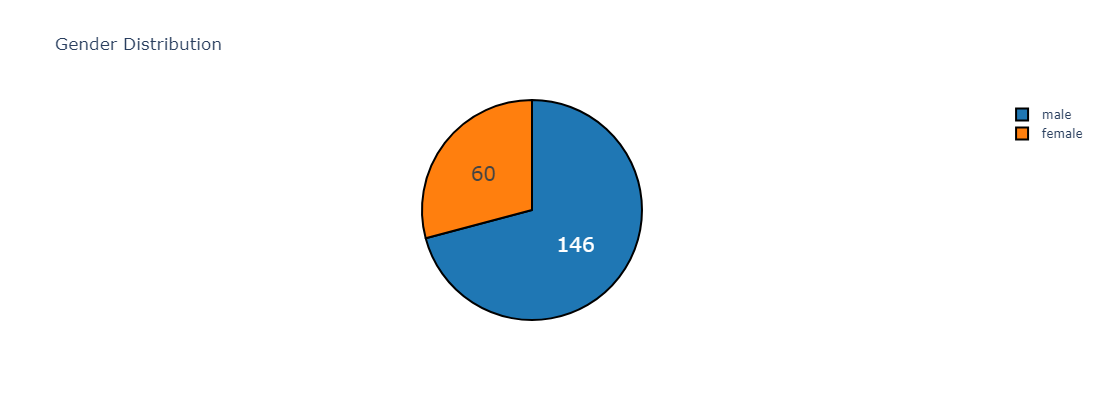

In [38]:
gender_counts = data_after['Gender'].value_counts()
labels = gender_counts.index.tolist()
values = gender_counts.values.tolist()

colors = ['#1f77b4', '#ff7f0e']  

fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=values
)])

fig.update_traces(
    hoverinfo='label+percent',  
    textinfo='value',  
    textfont_size=20, 
    marker=dict(
        colors=colors,  
        line=dict(color='#000000', width=2)  
    )
)

fig.update_layout(
    title='Gender Distribution',
    autosize=False,
    width=600,  
    height=400  
)

fig.show()


C:\Users\Muslim Aqeel\AppData\Local\Temp\ipykernel_8464\2979883927.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




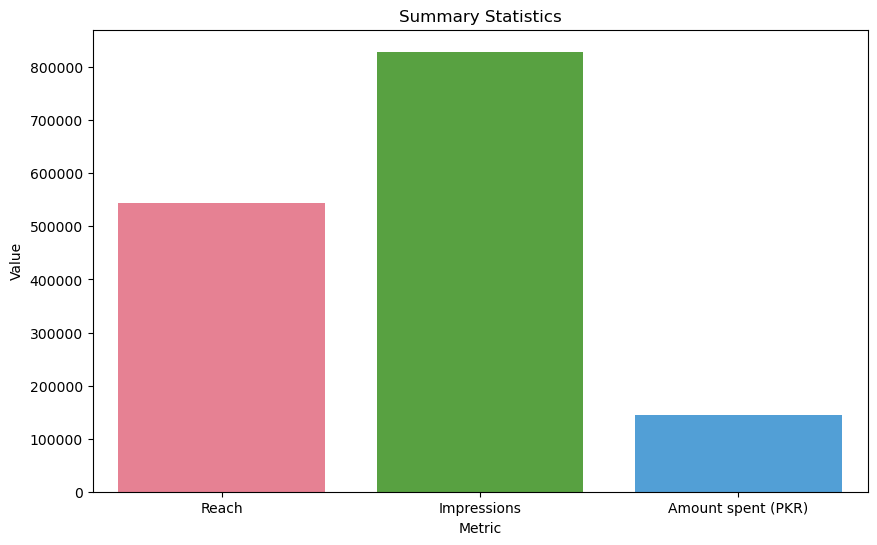

In [39]:
total_reach = data_after['Reach'].sum()
total_impression = data_after['Impressions'].sum()
total_amount = data_after['Amount spent (PKR)'].sum()

d_summary = pd.DataFrame({
    'Metric': ['Reach', 'Impressions', 'Amount spent (PKR)'],
    'Value': [total_reach, total_impression, total_amount]
})

plt.figure(figsize=(10, 6))
colors = sns.color_palette("husl", len(d_summary))
sns.barplot(x='Metric', y='Value', data=d_summary, palette=colors)
plt.title('Summary Statistics')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

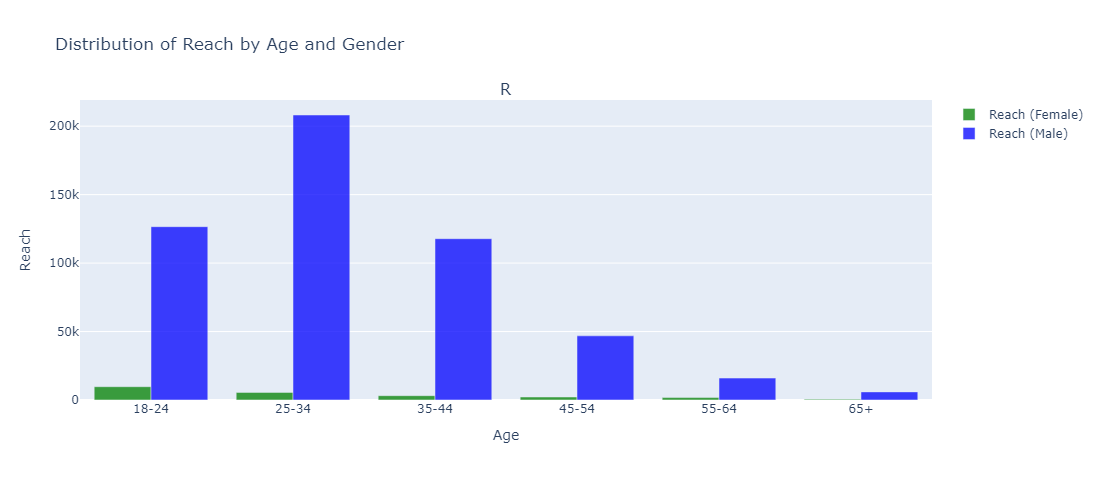

In [40]:
data_aggs = data_after.groupby(['Age', 'Gender']).agg({
    'Reach': 'sum',
    'Impressions': 'sum',
    'Amount spent (PKR)': 'sum',
    'Link clicks': 'sum'
}).reset_index()

data_aggs['Gender'] = data_aggs['Gender'].str.strip().str.capitalize()
colors = {'Male': 'blue', 'Female': 'green'}

fig = make_subplots(rows=1, cols=1, subplot_titles=('Reach by Age and Gender'))

for gender in data_aggs['Gender'].unique():
    filtered_data = data_aggs[data_aggs['Gender'] == gender]
    fig.add_trace(go.Bar(
        x=filtered_data['Age'],
        y=filtered_data['Reach'],
        name=f'Reach ({gender})',
        marker_color=colors.get(gender, 'gray'),  
        opacity=0.75  
    ), row=1, col=1)

fig.update_layout(
    title_text='Distribution of Reach by Age and Gender',
    xaxis_title='Age',
    yaxis_title='Reach',
    width=850,  
    height=480,  
    barmode='group'  
)

fig.show()


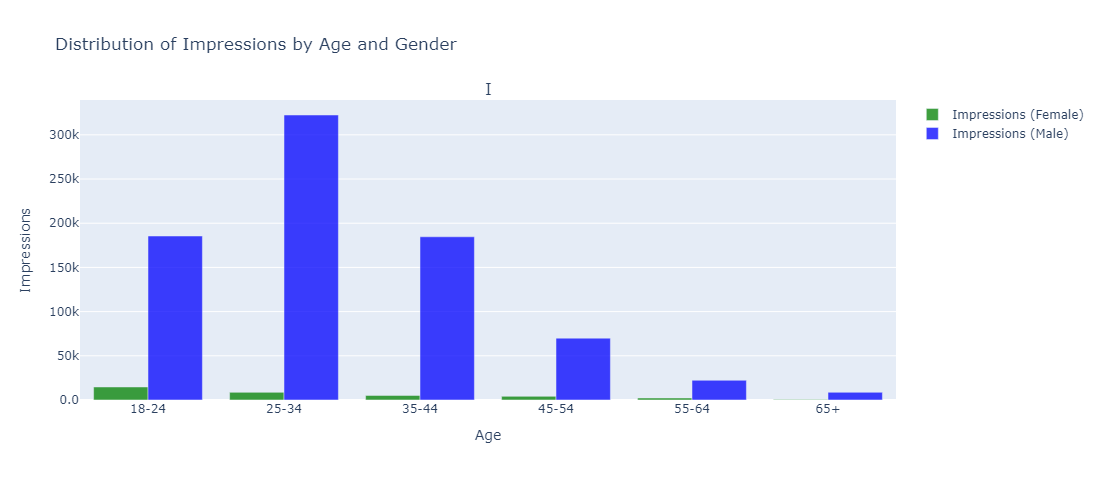

In [41]:
colors = {'Male': 'blue', 'Female': 'green'}

# Create the subplot
fig = make_subplots(rows=1, cols=1, subplot_titles=('Impressions by Age and Gender'))

# Loop through unique genders and create bar traces
for gender in data_aggs['Gender'].unique():
    filtered_data = data_aggs[data_aggs['Gender'] == gender]
    fig.add_trace(go.Bar(
        x=filtered_data['Age'],
        y=filtered_data['Impressions'],
        name=f'Impressions ({gender})',
        marker_color=colors.get(gender, 'gray'),  
        opacity=0.75  
    ), row=1, col=1)

# Update the layout and format y-axis to show numbers in 'k' (thousands)
fig.update_layout(
    title_text='Distribution of Impressions by Age and Gender',
    xaxis_title='Age',
    yaxis_title='Impressions',
    width=850,  
    height=480,  
    barmode='group',
    yaxis_tickformat='.2s',  # Use '.2s' to format numbers with metric prefixes (e.g., 800k)
)

# Show the figure
fig.show()

In [42]:
data_aggs['CPC (cost per link click)']= data_aggs['Amount spent (PKR)'] / data_aggs['Link clicks']
data_aggs['CTR']= data_aggs['Link clicks'] / data_aggs['Impressions']

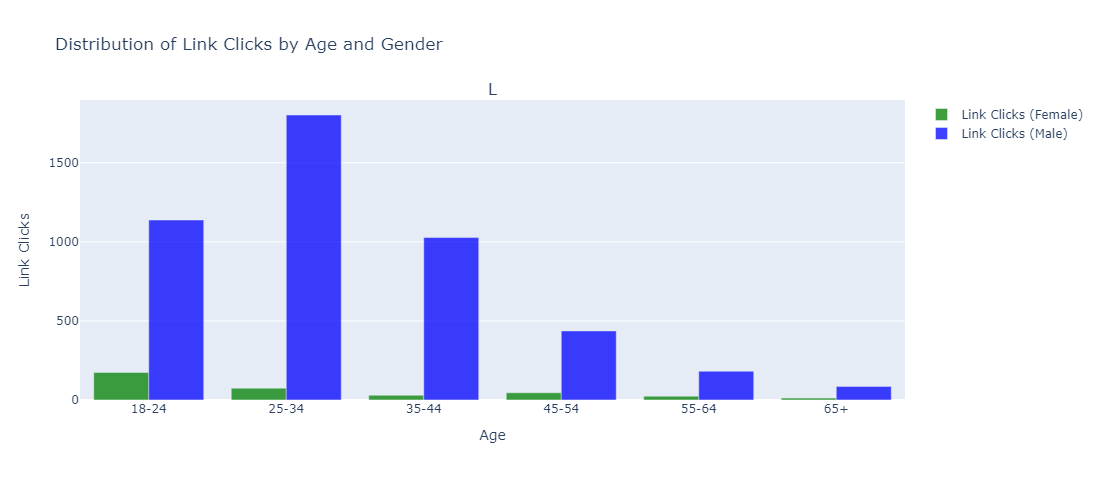

In [43]:
colors = {'Male': 'blue', 'Female': 'green'}

fig = make_subplots(rows=1, cols=1, subplot_titles=('Link Clicks by Age and Gender'))

for gender in data_aggs['Gender'].unique():
    filtered_data = data_aggs[data_aggs['Gender'] == gender]
    fig.add_trace(go.Bar(
        x=filtered_data['Age'],
        y=filtered_data['Link clicks'],
        name=f'Link Clicks ({gender})',
        marker_color=colors.get(gender, 'gray'),  
        opacity=0.75  
    ), row=1, col=1)

fig.update_layout(
    title_text='Distribution of Link Clicks by Age and Gender',
    xaxis_title='Age',
    yaxis_title='Link Clicks',
    width=850,  
    height=480, 
    barmode='group' 
)

fig.show()

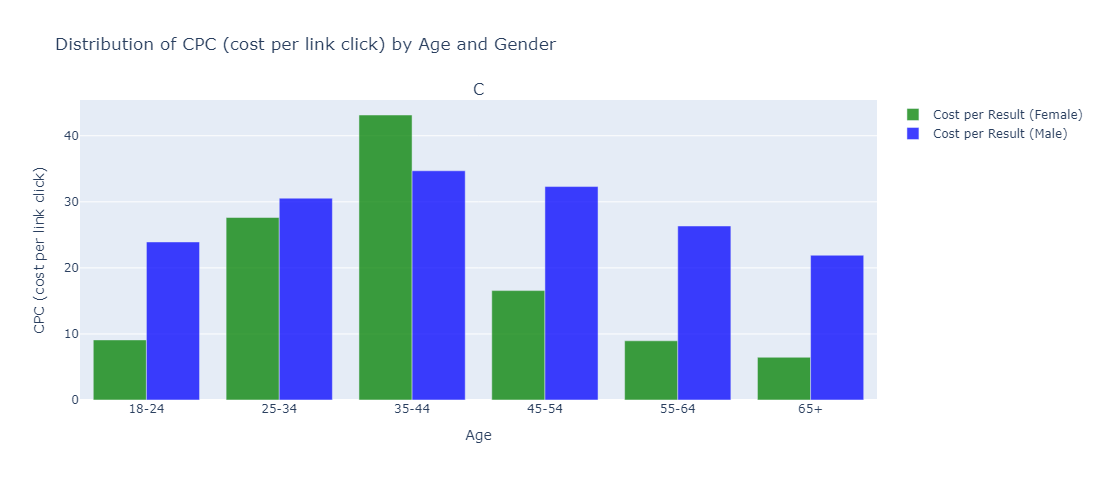

In [44]:
colors = {'Male': 'blue', 'Female': 'green'}

fig_cost_per_result = make_subplots(rows=1, cols=1, subplot_titles=('CPC (cost per link click) by Age and Gender'))

for gender in data_aggs['Gender'].unique():
    filtered_data = data_aggs[data_aggs['Gender'] == gender]
    
    fig_cost_per_result.add_trace(go.Bar(
        x=filtered_data['Age'],
        y=filtered_data['CPC (cost per link click)'],
        name=f'Cost per Result ({gender})',
        marker_color=colors.get(gender, 'gray'),  
        opacity=0.75  
    ))

fig_cost_per_result.update_layout(
    title_text='Distribution of CPC (cost per link click) by Age and Gender',
    xaxis_title='Age',
    yaxis_title='CPC (cost per link click)',
    width=850,  
    height=480,  
    barmode='group'  
)

# Show the plot
fig_cost_per_result.show()

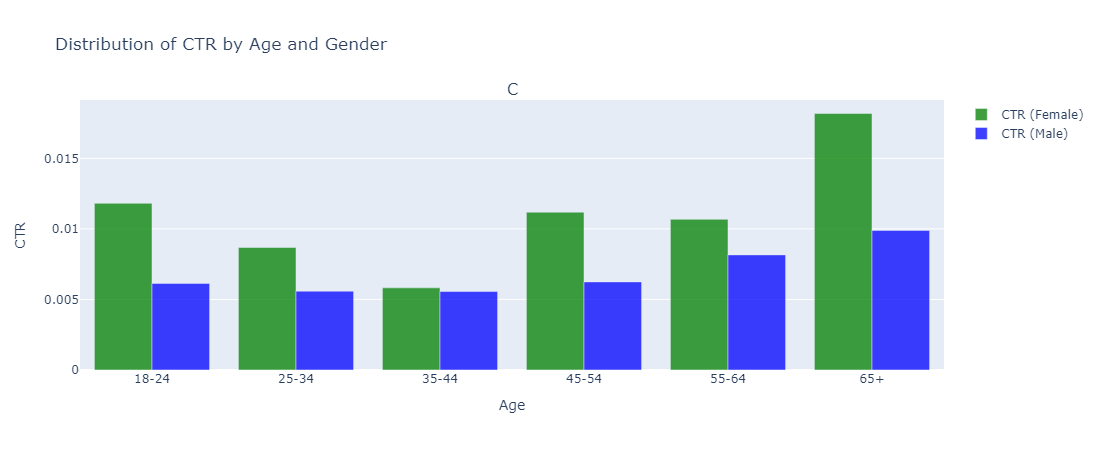

In [45]:
fig_ctr = make_subplots(rows=1, cols=1, subplot_titles=('CTR by Age and Gender'))

for gender in data_aggs['Gender'].unique():
    filtered_data = data_aggs[data_aggs['Gender'] == gender]
    
    fig_ctr.add_trace(go.Bar(
        x=filtered_data['Age'],
        y=filtered_data['CTR'],
        name=f'CTR ({gender})',
        marker_color=colors.get(gender, 'gray'),  
        opacity=0.75 
    ))

fig_ctr.update_layout(
    title_text='Distribution of CTR by Age and Gender',
    xaxis_title='Age',
    yaxis_title='CTR',
    width=880,  
    height=450,  
    barmode='group'  
)

# Show the plot
fig_ctr.show()

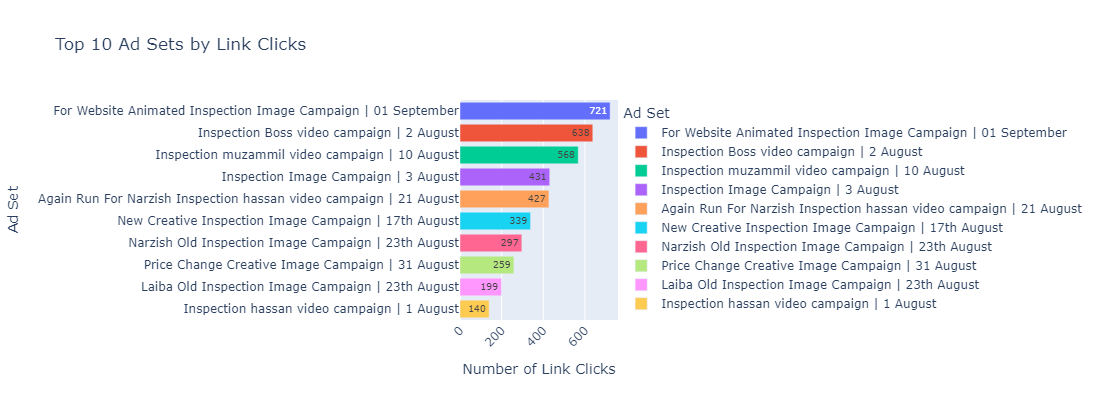

In [46]:
adset_link_clicks = data_after.groupby('Ad name')['Link clicks'].sum().reset_index()

top_10_adsets = adset_link_clicks.sort_values(by='Link clicks', ascending=False).head(10)

fig = px.bar(top_10_adsets, 
             x='Link clicks', 
             y='Ad name', 
             title='Top 10 Ad Sets by Link Clicks',
             labels={'Link clicks': 'Number of Link Clicks', 'Ad name': 'Ad Set'},
             orientation='h', 
             color='Ad name',  
             color_discrete_sequence=px.colors.qualitative.Plotly,
             text='Link clicks')  

fig.update_layout(
    xaxis_title='Number of Link Clicks',
    yaxis_title='Ad Set',
    width=1400,  
    height=400,  
    xaxis=dict(tickangle=-45)  
)

fig.show()

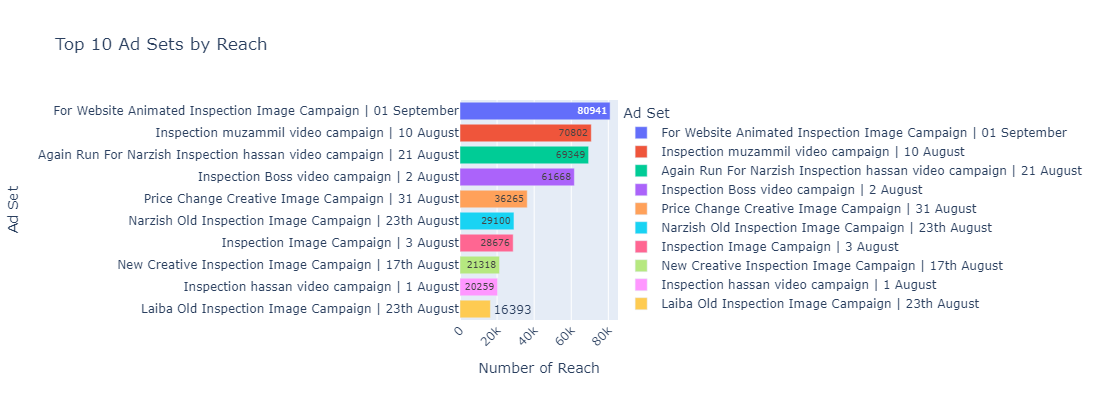

In [47]:
adset_reach = data_after.groupby('Ad name')['Reach'].sum().reset_index()

top_10_adsets_reach = adset_reach.sort_values(by='Reach', ascending=False).head(10)

fig = px.bar(top_10_adsets_reach, 
             x='Reach', 
             y='Ad name', 
             title='Top 10 Ad Sets by Reach',
             labels={'Reach': 'Number of Reach', 'Ad name': 'Ad Set'},
             orientation='h', 
             color='Ad name',  
             color_discrete_sequence=px.colors.qualitative.Plotly,
             text='Reach')  

fig.update_layout(
    xaxis_title='Number of Reach',
    yaxis_title='Ad Set',
    width=1400,  
    height=400,  
    xaxis=dict(tickangle=-45)  
)


fig.show()

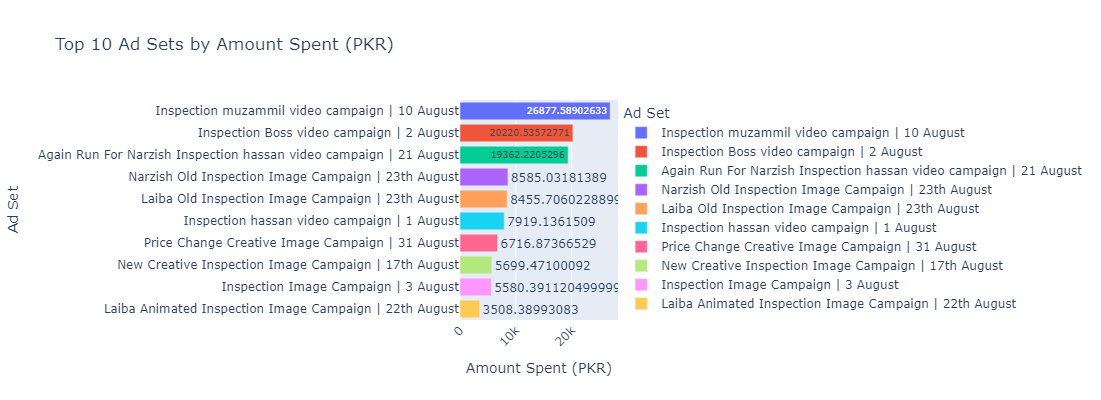

In [48]:
adset_amount_spent = data_after.groupby('Ad name')['Amount spent (PKR)'].sum().reset_index()
top_10_adsets_amount_spent = adset_amount_spent.sort_values(by='Amount spent (PKR)', ascending=False).head(10)

fig = px.bar(top_10_adsets_amount_spent, 
             x='Amount spent (PKR)', 
             y='Ad name', 
             title='Top 10 Ad Sets by Amount Spent (PKR)',
             labels={'Amount spent (PKR)': 'Amount Spent (PKR)', 'Ad name': 'Ad Set'},
             orientation='h', 
             color='Ad name',  
             color_discrete_sequence=px.colors.qualitative.Plotly,
             text='Amount spent (PKR)')  

fig.update_layout(
    xaxis_title='Amount Spent (PKR)',
    yaxis_title='Ad Set',
    width=1400,  
    height=400,  
    xaxis=dict(tickangle=-45) 
)



fig.show()

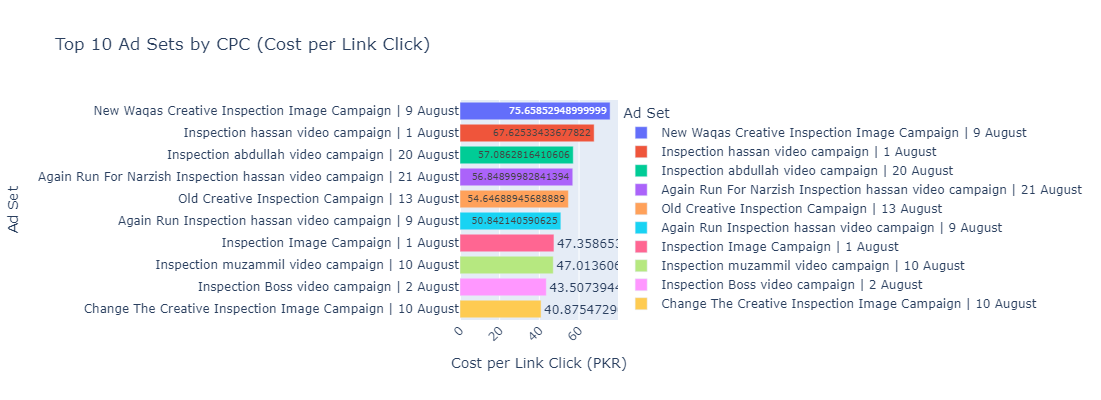

In [49]:
data_after['CPC'] = data_after['Amount spent (PKR)'] / data_after['Link clicks']

adset_cpc = data_after.groupby('Ad name')['CPC'].mean().reset_index()

top_10_adsets_cpc = adset_cpc.sort_values(by='CPC', ascending=False).head(10)

fig = px.bar(top_10_adsets_cpc, 
             x='CPC', 
             y='Ad name', 
             title='Top 10 Ad Sets by CPC (Cost per Link Click)',
             labels={'CPC': 'Cost per Link Click (PKR)', 'Ad name': 'Ad Set'},
             orientation='h', 
             color='Ad name',  
             color_discrete_sequence=px.colors.qualitative.Plotly,
             text='CPC')  

fig.update_layout(
    xaxis_title='Cost per Link Click (PKR)',
    yaxis_title='Ad Set',
    width=1400,  
    height=400,  
    xaxis=dict(tickangle=-45)  
)

fig.show()

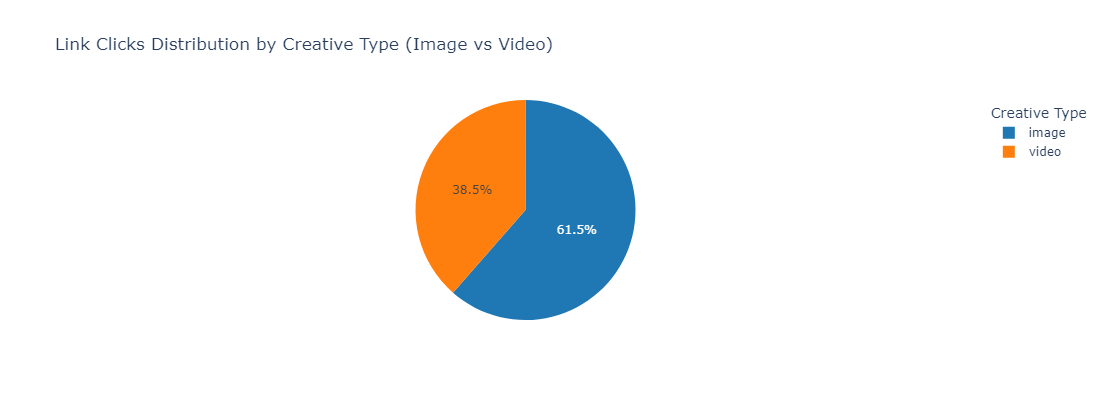

In [50]:
colors = ['#1f77b4', '#ff7f0e']

link_clicks_by_creative = data_after.groupby('Creative')['Link clicks'].sum().reset_index()

fig = px.pie(link_clicks_by_creative, 
             names='Creative', 
             values='Link clicks',
             title='Link Clicks Distribution by Creative Type (Image vs Video)',
             color_discrete_sequence=colors)

fig.update_layout(
    width=600,
    height=400,
    legend_title='Creative Type',
    showlegend=True,
)

fig.show()

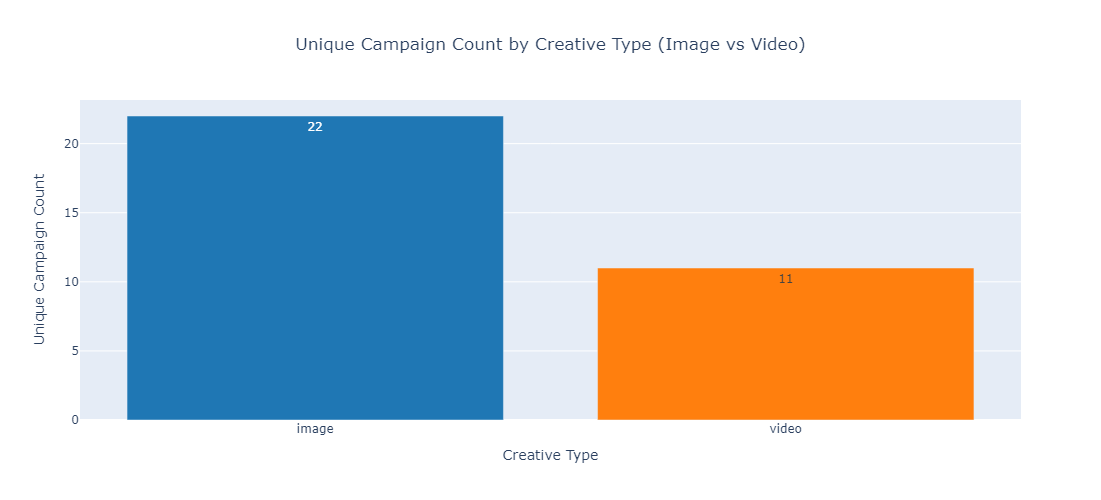

In [51]:
unique_campaigns_by_creative = data_after.groupby('Creative')['Ad name'].nunique().reset_index()

unique_campaigns_by_creative.columns = ['Creative', 'Unique Campaign Count']

fig = px.bar(unique_campaigns_by_creative, 
             x='Creative', 
             y='Unique Campaign Count', 
             color='Creative',
             title='Unique Campaign Count by Creative Type (Image vs Video)',
             text='Unique Campaign Count',  
             color_discrete_sequence=['#1f77b4', '#ff7f0e'])  


fig.update_layout(
    width=700,
    height=500,
    xaxis_title='Creative Type',
    yaxis_title='Unique Campaign Count',
    showlegend=False,  
    title_x=0.5  
)


fig.show()

C:\Users\Muslim Aqeel\AppData\Local\Temp\ipykernel_8464\2017071199.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





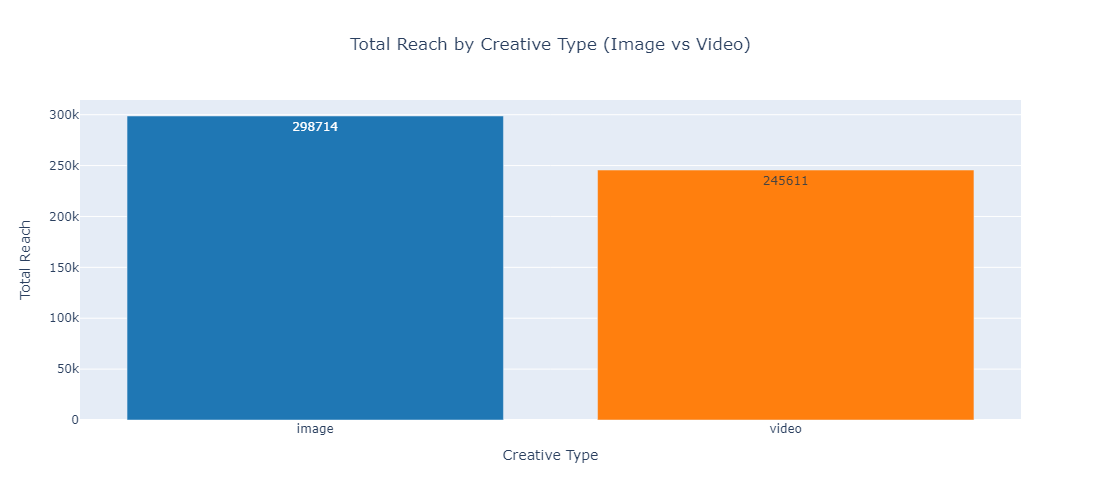

In [52]:
data_after['Creative'].fillna('image', inplace=True)

# Group by 'Creative' and calculate the total reach for each type
reach_by_creative = data_after.groupby('Creative')['Reach'].sum().reset_index()

# Rename columns
reach_by_creative.columns = ['Creative', 'Total Reach']

# Create bar plot using Plotly Express
fig = px.bar(reach_by_creative, 
             x='Creative', 
             y='Total Reach', 
             color='Creative',
             title='Total Reach by Creative Type (Image vs Video)',
             text='Total Reach',  
             color_discrete_sequence=['#1f77b4', '#ff7f0e'])  

# Update layout
fig.update_layout(
    width=700,
    height=500,
    xaxis_title='Creative Type',
    yaxis_title='Total Reach',
    showlegend=False,  
    title_x=0.5  
)

# Show the plot
fig.show()

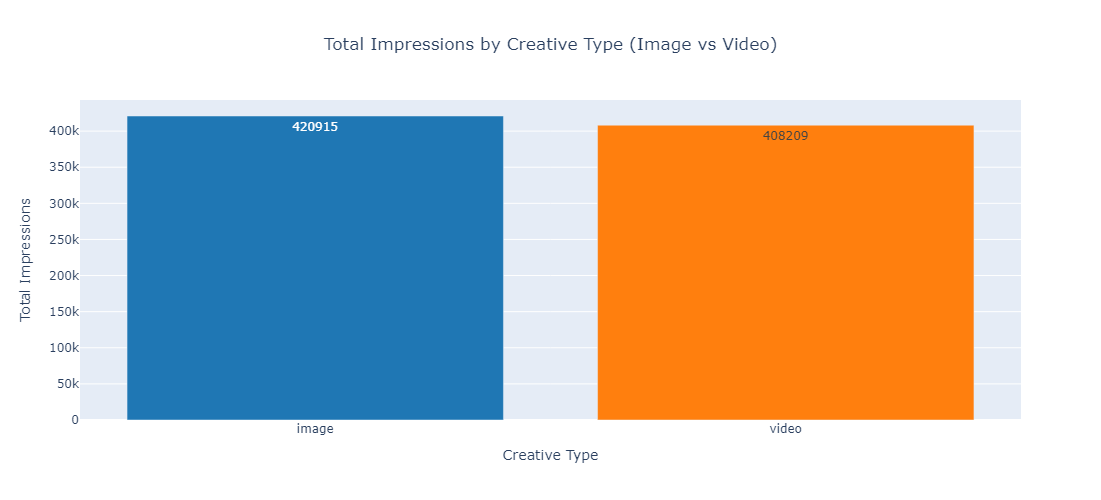

In [53]:
impressions_by_creative = data_after.groupby('Creative')['Impressions'].sum().reset_index()

# Rename columns
impressions_by_creative.columns = ['Creative', 'Total Impressions']

# Create bar plot for Impressions
fig_impressions = px.bar(impressions_by_creative, 
                         x='Creative', 
                         y='Total Impressions', 
                         color='Creative',
                         title='Total Impressions by Creative Type (Image vs Video)',
                         text='Total Impressions',  
                         color_discrete_sequence=['#1f77b4', '#ff7f0e'])

# Update layout
fig_impressions.update_layout(
    width=700,
    height=500,
    xaxis_title='Creative Type',
    yaxis_title='Total Impressions',
    showlegend=False,
    title_x=0.5
)

# Show the plot
fig_impressions.show()

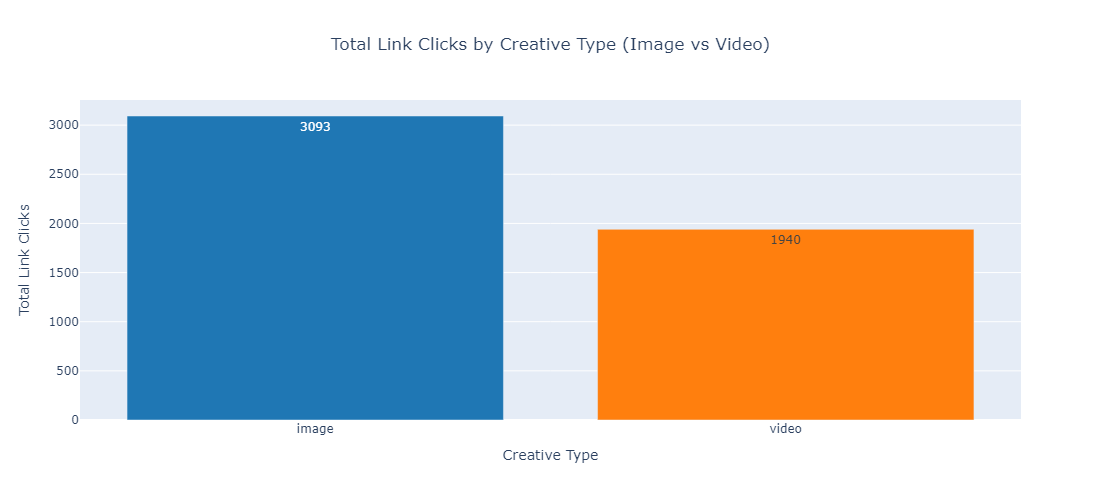

In [54]:
clicks_by_creative = data_after.groupby('Creative')['Link clicks'].sum().reset_index()

# Rename columns
clicks_by_creative.columns = ['Creative', 'Total Link Clicks']

# Create bar plot for Link Clicks
fig_clicks = px.bar(clicks_by_creative, 
                    x='Creative', 
                    y='Total Link Clicks', 
                    color='Creative',
                    title='Total Link Clicks by Creative Type (Image vs Video)',
                    text='Total Link Clicks',  
                    color_discrete_sequence=['#1f77b4', '#ff7f0e'])

# Update layout
fig_clicks.update_layout(
    width=700,
    height=500,
    xaxis_title='Creative Type',
    yaxis_title='Total Link Clicks',
    showlegend=False,
    title_x=0.5
)

# Show the plot
fig_clicks.show()

C:\Users\Muslim Aqeel\AppData\Local\Temp\ipykernel_8464\1553663314.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





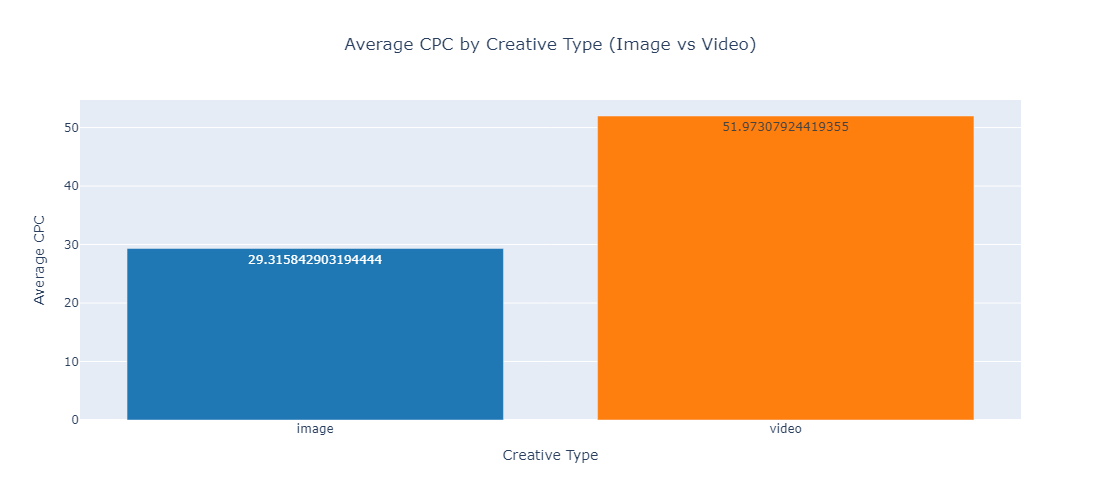

In [55]:
data_after['Creative'].fillna('image', inplace=True)

# Group by 'Creative' and calculate the average CPC
cpc_by_creative = data_after.groupby('Creative')['CPC (cost per link click)'].mean().reset_index()

# Rename columns
cpc_by_creative.columns = ['Creative', 'Average CPC']

# Create bar plot for CPC
fig_cpc = px.bar(cpc_by_creative, 
                 x='Creative', 
                 y='Average CPC', 
                 color='Creative',
                 title='Average CPC by Creative Type (Image vs Video)',
                 text='Average CPC',  
                 color_discrete_sequence=['#1f77b4', '#ff7f0e'])

# Update layout
fig_cpc.update_layout(
    width=700,
    height=500,
    xaxis_title='Creative Type',
    yaxis_title='Average CPC',
    showlegend=False,
    title_x=0.5
)

# Show the plot
fig_cpc.show()

In [56]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
data_after.columns = data_after.columns.str.replace(' ', '_')

model = smf.mixedlm('Link_clicks ~ Age', data_after, groups=data_after['Ad_name']).fit()

print("Hierarchical Model Summary:")
print(model.summary())


Hierarchical Model Summary:
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Link_clicks
No. Observations: 206     Method:             REML       
No. Groups:       28      Scale:              1388.2756  
Min. group size:  2       Log-Likelihood:     -1031.3750 
Max. group size:  18      Converged:          Yes        
Mean group size:  7.4                                    
---------------------------------------------------------
              Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------
Intercept     30.781    6.910  4.455 0.000  17.238 44.323
Age[T.25-34]  14.121    8.255  1.711 0.087  -2.059 30.301
Age[T.35-44]  -3.802    8.476 -0.449 0.654 -20.414 12.811
Age[T.45-54] -20.324    8.259 -2.461 0.014 -36.511 -4.136
Age[T.55-64] -25.848    9.484 -2.725 0.006 -44.437 -7.260
Age[T.65+]   -30.113   10.348 -2.910 0.004 -50.396 -9.831
Group Var    355.840    4.610                         

In [57]:
data_after['Age'].replace({'18-24': '1', '25-34': '2', '35-44': '3', '45-54': '4', '55-64': '5', '65+': '6'}, inplace=True)
data_after['Age'] = data_after['Age'].astype(int)

# Replace values in 'Gender' and convert to integer
data_after['Gender'].replace({'male': '1', 'female': '2'}, inplace=True)
data_after['Gender'] = data_after['Gender'].astype(int)

# Replace values in 'Creative' and convert to integer
data_after['Creative'].replace({'video': '1', 'image': '2'}, inplace=True)
data_after['Creative'] = data_after['Creative'].astype(int)

C:\Users\Muslim Aqeel\AppData\Local\Temp\ipykernel_8464\3022719466.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\Muslim Aqeel\AppData\Local\Temp\ipykernel_8464\3022719466.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [58]:
data_after.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 0 to 496
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               206 non-null    int32  
 1   Gender                            206 non-null    int32  
 2   Ad_name                           206 non-null    object 
 3   Reach                             206 non-null    int64  
 4   Impressions                       206 non-null    int64  
 5   Frequency                         206 non-null    float64
 6   Result_Type                       143 non-null    object 
 7   Results                           143 non-null    float64
 8   Cost_per_result                   143 non-null    float64
 9   Amount_spent_(PKR)                206 non-null    float64
 10  CPM_(cost_per_1,000_impressions)  206 non-null    float64
 11  Link_clicks                       206 non-null    float64
 12  CPC_(cost_per

## Bayesian Linear Regression Model for Predicting Cost Per Result

In [59]:
age = data_after['Age'].values
reach = data_after['Reach'].values
impressions = data_after['Impressions'].values
cost_per_result = data_after['CPC_(cost_per_link_click)'].values

In [60]:
with pm.Model() as bayesian_model:
    
    
    beta_age = pm.Normal('beta_age', mu=0, sigma=1)
    beta_reach = pm.Normal('beta_reach', mu=0, sigma=1)
    beta_impressions = pm.Normal('beta_impressions', mu=0, sigma=1)
    intercept = pm.Normal('intercept', mu=0, sigma=1)
    
   
    mu = (beta_age * age + beta_reach * reach + beta_impressions * impressions + intercept)
    
    
    sigma = pm.HalfNormal('sigma', sigma=1)
    likelihood = pm.Normal('likelihood', mu=mu, sigma=sigma, observed=cost_per_result)
    
    
    trace = pm.sample(1000, return_inferencedata=True)
    

pm.summary(trace)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta_age, beta_reach, beta_impressions, intercept, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 41 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_age,5.891,0.413,5.158,6.712,0.013,0.009,1020.0,1122.0,1.0
beta_impressions,0.001,0.001,-0.001,0.003,0.000,0.000,730.0,857.0,1.0
beta_reach,-0.000,0.002,-0.004,0.003,0.000,0.000,737.0,911.0,1.0
intercept,5.332,0.950,3.558,7.076,0.027,0.019,1233.0,994.0,1.0
sigma,18.912,0.439,18.108,19.773,0.012,0.008,1416.0,1155.0,1.0


## Predictive Modelling Using Deep Neural Network

In [61]:
features = ['Creative', 'Age', 'Gender', 'Reach', 'Impressions']
target = ['Link_clicks', 'CPC', 'Amount_spent_(PKR)']

X = data_after[features]
y = data_after[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the neural network model
model_dl = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(y.shape[1])
])

# Compile the model
model_dl.compile(optimizer=Adam(), loss='mean_squared_error')

# Train the model
model_dl.fit(X_train, y_train, epochs=100, batch_size=5, validation_split=0.2, verbose=1)

# Make predictions
y_pred = model_dl.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='raw_values')
print('Mean Squared Error for each target:', mse)
print('R^2 Score for each target:', r2)

Epoch 1/100
27/27 [==============================] - 1s 10ms/step - loss: 267817.5938 - val_loss: 910183.1875
Epoch 2/100
27/27 [==============================] - 0s 3ms/step - loss: 158170.0469 - val_loss: 583588.4375
Epoch 3/100
27/27 [==============================] - 0s 3ms/step - loss: 114693.6719 - val_loss: 689123.0000
Epoch 4/100
27/27 [==============================] - 0s 3ms/step - loss: 58865.7188 - val_loss: 942532.6875
Epoch 5/100
27/27 [==============================] - 0s 3ms/step - loss: 54035.5625 - val_loss: 642951.5625
Epoch 6/100
27/27 [==============================] - 0s 3ms/step - loss: 42543.2305 - val_loss: 641010.6250
Epoch 7/100
27/27 [==============================] - 0s 3ms/step - loss: 61257.8164 - val_loss: 830271.8750
Epoch 8/100
27/27 [==============================] - 0s 3ms/step - loss: 40668.1523 - val_loss: 614880.1875
Epoch 9/100
27/27 [==============================] - 0s 3ms/step - loss: 38019.2578 - val_loss: 634155.4375
Epoch 10/100
27/27 [====

In [65]:
creative = int(input("Enter the Creative  (0 for Image, 1 for Video ): "))
gender = int(input("Enter Gender (0 for Female, 1 for Male): "))
age = int(input("Enter Age Group (1 for '18-24', 2 for '25-34', 3 for '35-44', 4 for '45-54', 5 for '55-64', 6 for '65+'): "))
reach = int(input("Enter Reach: "))
impressions = int(input("Enter Impressions: "))

input_data = pd.DataFrame({
    'Creative': [creative],
    'Gender': [gender],
    'Age': [age],
    'Reach': [reach],
    'Impressions': [impressions]
})


input_data = input_data.astype(np.float32)


predicted_values = model_dl.predict(input_data)


print("Predicted Link Clicks:", predicted_values[0][0])
print("Predicted Cost per Result:", predicted_values[0][1])
print("Predicted Amount Spent (PKR):", predicted_values[0][2])

Enter the Creative  (0 for Image, 1 for Video ):  1
Enter Gender (0 for Female, 1 for Male):  1
Enter Age Group (1 for '18-24', 2 for '25-34', 3 for '35-44', 4 for '45-54', 5 for '55-64', 6 for '65+'):  2
Enter Reach:  44444
Enter Impressions:  777777


1/1 [==============================] - 0s 21ms/step
Predicted Link Clicks: -4530.7617
Predicted Cost per Result: 23388.295
Predicted Amount Spent (PKR): 137439.86


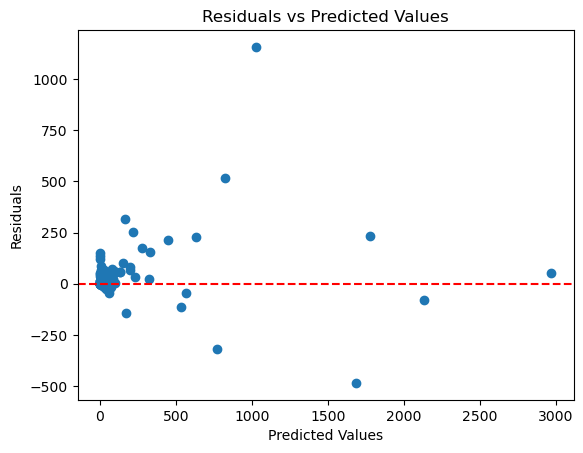

In [66]:
residuals = y_test - y_pred

# Plot residuals
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.axhline(0, color='red', linestyle='--')
plt.show()